# NW ISL1 differential-expression analysis


In [ ]:
knitr::opts_chunk$set(echo = TRUE)



## Loading packages



In [19]:
library(ggplot2)
library(ggrepel)
library(ggpubr)
library(stringr)
library(MASS)
library(RColorBrewer)
library(DESeq2)
library(viridis)
library(ggpointdensity)
library(tidyverse)
library(data.table)
library(pheatmap)
library(ComplexHeatmap)
library(UpSetR)
library(readxl)
library(ggsci)
library(ggprism)
library(ragg)
library(edgeR)
library(dplyr)
library(tidyr)
library(limma)
theme_set(theme_classic(base_size = 15))

personal_path = "/fh/working/sun_w/sshen/MorPhiC"
path = "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment/"
dat_path = file.path(path, "DRACC-processed/NW_exchange_experiment_DRACC_processed_March2026/Tables")



## Read in meta data



In [20]:
meta = fread(file.path(personal_path, "NW_meta_data.tsv"), data.table = FALSE)



## Read in gene count data



In [21]:
cts = fread(file.path(dat_path, "genesCounts.csv"), data.table = FALSE)
colnames(cts) <- gsub("_S[0-9]+_L[0-9]+$", "", colnames(cts))
# Align counts with meta data
stopifnot(
  setequal(meta$Name, names(cts)[-1]),
  !any(duplicated(meta$Name)),
  !any(duplicated(names(cts)[-1]))
)
meta = meta[match(names(cts)[-1], meta$Name), ]
# To matrix
cts_dat = data.matrix(cts[, -1])
rownames(cts_dat) = cts$Name


In [22]:
meta

,Name,Center,Replicate,Condition,Dcondition,ko_gene
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,23247XR-05-42,UCSF,3,control plus DMSO,UCSF_CLONE_D1_DMSO,WT
2,23247XR-05-53,UCSF,2,control plus DMSO,UCSF_AAVS1_DMSO,WT
3,23247XR-05-55,UCSF,1,control plus DOX,UCSF_AAVS1_DOX,WT
4,23247XR-05-47,UCSF,2,control plus DMSO,UCSF_CLONE_B1 DMSO,WT
5,23247XR-05-35,MSK,2,KOLF_Parent_NA none,MSK_CLONE_05,KO
6,23247XR-05-41,UCSF,2,control plus DMSO,UCSF_CLONE_D1_DMSO,WT
7,23247XR-05-52,UCSF,1,control plus DMSO,UCSF_AAVS1_DMSO,WT
8,23247XR-05-56,UCSF,2,control plus DOX,UCSF_AAVS1_DOX,WT
9,23247XR-05-05,Parent,2,control plus DMSO,KOLF_PARENT_DMSO,WT



### Exclude genes without annotation



In [23]:
# Read in gene annotation
gene_anno = fread("/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv")
dim(gene_anno)
cts = cts[cts$Name %in% gene_anno$ensembl_gene_id, ]
cts_dat = cts_dat[rownames(cts_dat) %in% gene_anno$ensembl_gene_id, ]

gene_info = data.frame(
  apply(cts_dat, 1, min), 
  apply(cts_dat, 1, median), 
  apply(cts_dat, 1, \(x) quantile(x, probs = 0.75)), 
  apply(cts_dat, 1, max)
)
gene_info[1:2, ]
names(gene_info) = c("min", "median", "q75", "max")
cts_dat_before_q75 <- cts_dat
gene_info_before_q75 <- gene_info
summary(gene_info)
table(gene_info$q75 > 0)

# Keep the DE universe to q75-passing annotated genes. The max(mean WT CPM,
# mean KO CPM) filter is applied only after DE testing and saved separately.
w2kp = which(gene_info$q75 > 0)
cts_dat_all_annotated <- cts_dat
gene_info_all_annotated <- gene_info
cts_dat_q75 <- cts_dat[w2kp, , drop = FALSE]
gene_info_q75 <- gene_info[w2kp, , drop = FALSE]
cts_dat <- cts_dat_q75
gene_info <- gene_info_q75
cts <- cts[cts$Name %in% rownames(cts_dat), , drop = FALSE]

group_mean_cpm_metrics <- function(counts, group) {
  group <- droplevels(factor(group))
  stopifnot(ncol(counts) == length(group), all(table(group) > 0))

  y_cpm <- edgeR::DGEList(counts = counts)
  y_cpm <- edgeR::calcNormFactors(y_cpm)
  cpm_mat <- edgeR::cpm(y_cpm, log = FALSE)
  group_mean_cpm <- vapply(
    levels(group),
    function(group_level) {
      rowMeans(cpm_mat[, group == group_level, drop = FALSE], na.rm = TRUE)
    },
    numeric(nrow(cpm_mat))
  )
  rownames(group_mean_cpm) <- rownames(cpm_mat)
  group_mean_cpm <- as.data.frame(group_mean_cpm, check.names = FALSE)
  colnames(group_mean_cpm) <- paste0("mean_CPM_", make.names(colnames(group_mean_cpm)))
  group_mean_cpm$gene_id <- rownames(group_mean_cpm)
  mean_cols <- grep("^mean_CPM_", colnames(group_mean_cpm), value = TRUE)
  group_mean_cpm$max_mean_CPM <- apply(
    as.matrix(group_mean_cpm[, mean_cols, drop = FALSE]),
    1,
    max,
    na.rm = TRUE
  )

  tibble::as_tibble(group_mean_cpm) %>%
    dplyr::relocate(gene_id)
}

add_group_mean_cpm_metrics <- function(results, counts, group, gene_col = NULL) {
  cpm_metrics <- group_mean_cpm_metrics(counts, group)
  result_gene_ids <- if (is.null(gene_col)) {
    rownames(results)
  } else {
    results[[gene_col]]
  }
  metric_cols <- setdiff(colnames(cpm_metrics), "gene_id")
  for (metric_col in metric_cols) {
    results[[metric_col]] <- cpm_metrics[[metric_col]][match(result_gene_ids, cpm_metrics$gene_id)]
  }
  results
}

filter_results_by_group_mean_cpm <- function(results, counts, group, min_cpm = 1, gene_col = NULL, apply_cpm_filter = FALSE) {
  results <- add_group_mean_cpm_metrics(results, counts, group, gene_col = gene_col)
  result_gene_ids <- if (is.null(gene_col)) {
    rownames(results)
  } else {
    results[[gene_col]]
  }
  if (exists("gene_info") && "q75" %in% colnames(gene_info)) {
    results$q75 <- gene_info$q75[match(result_gene_ids, rownames(gene_info))]
    results$q75_pass <- is.finite(results$q75) & results$q75 > 0
  } else {
    results$q75_pass <- TRUE
  }

  logfc_col <- intersect(c("logFC", "log2FoldChange"), colnames(results))[1]
  q_col <- intersect(c("qvalue", "padj", "adj.P.Val"), colnames(results))[1]
  if (!is.na(logfc_col) && !is.na(q_col)) {
    results$threshold <- results$q75_pass &
      !is.na(results[[q_col]]) & results[[q_col]] < 0.05 &
      is.finite(results[[logfc_col]]) & abs(results[[logfc_col]]) > 1 &
      is.finite(results$max_mean_CPM) & results$max_mean_CPM >= min_cpm
  }

  if (apply_cpm_filter) {
    results <- results[is.finite(results$max_mean_CPM) & results$max_mean_CPM >= min_cpm, , drop = FALSE]
  }
  results
}

fit_limma_with_optional_duplicate_correlation <- function(y, design, block = NULL, fit_label = NULL, plot = FALSE) {
  first_voom <- limma::voom(y, design, plot = plot)
  if (is.null(block)) {
    fit <- limma::lmFit(first_voom, design)
    fit$voom_passes <- 1L
    fit$duplicate_correlation <- NA_real_
    fit$sample_ids <- colnames(y$counts)
    fit$design <- design
    return(fit)
  }

  block <- droplevels(factor(block))
  stopifnot(length(block) == ncol(first_voom$E), !anyNA(block))
  block_counts <- table(block)
  repeated_blocks <- sum(block_counts > 1)
  label <- if (is.null(fit_label) || is.na(fit_label) || fit_label == "") {
    ""
  } else {
    paste0(" for ", fit_label)
  }

  if (nlevels(block) > 1 && repeated_blocks > 1) {
    corfit_first <- limma::duplicateCorrelation(first_voom, design, block = block)
    second_voom <- limma::voom(
      y, design, plot = plot, block = block, correlation = corfit_first$consensus
    )
    corfit_second <- limma::duplicateCorrelation(second_voom, design, block = block)
    message(sprintf(
      "Estimated duplicate-correlation%s (first/second pass): %.3f / %.3f",
      label, corfit_first$consensus, corfit_second$consensus
    ))
    fit <- limma::lmFit(
      second_voom, design, block = block, correlation = corfit_second$consensus
    )
    fit$voom_passes <- 2L
    fit$duplicate_correlation_first_pass <- corfit_first$consensus
    fit$duplicate_correlation <- corfit_second$consensus
    fit$block <- block
    fit$design <- design
    fit$sample_ids <- colnames(y$counts)
    return(fit)
  }

  message(sprintf(
    "Skipping duplicate-correlation%s: only %d repeated clone/block level(s).",
    label,
    repeated_blocks
  ))
  fit <- limma::lmFit(first_voom, design)
  fit$voom_passes <- 1L
  fit$duplicate_correlation <- NA_real_
  fit$block <- block
  fit$design <- design
  fit$sample_ids <- colnames(y$counts)
  fit
}

fit_limma_group_model <- function(counts, group, block = NULL, fit_label = NULL) {
  group <- factor(group, levels = c("WT", "KO"))
  stopifnot(ncol(counts) == length(group), all(table(group) > 0))
  design <- model.matrix(~ 0 + group)
  colnames(design) <- c("WT", "KO")

  y <- edgeR::DGEList(counts)
  y <- edgeR::calcNormFactors(y)
  fit <- fit_limma_with_optional_duplicate_correlation(y, design, block = block, fit_label = fit_label)
  contrast <- limma::makeContrasts(KOvsWT = KO - WT, levels = design)
  fit <- limma::eBayes(limma::contrasts.fit(fit, contrast))
  list(fit = fit, design = design, block = block, voom_passes = fit$voom_passes, duplicate_correlation = fit$duplicate_correlation)
}


[1] 62754     8

,apply.cts_dat..1..min.,apply.cts_dat..1..median.,apply.cts_dat..1..function.x..quantile.x..probs...0.75..,apply.cts_dat..1..max.
,<int>,<int>,<dbl>,<int>
ENSG00000268674,0,0,0,0
ENSG00000271254,785,1161,1323,1927


      min               median              q75              max         
 Min.   :     0.0   Min.   :     0.0   Min.   :     0   Min.   :      0  
 1st Qu.:     0.0   1st Qu.:     0.0   1st Qu.:     0   1st Qu.:      1  
 Median :     0.0   Median :     2.0   Median :     4   Median :     12  
 Mean   :   546.4   Mean   :   995.9   Mean   :  1210   Mean   :   1871  
 3rd Qu.:   226.2   3rd Qu.:   467.0   3rd Qu.:   574   3rd Qu.:    909  
 Max.   :376699.0   Max.   :589762.0   Max.   :694572   Max.   :1156270  


FALSE  TRUE 
14914 23678 

comparison,filter_stage,n_genes,n_pass_cpm_0_1,n_pass_cpm_0_5,n_pass_cpm_1,n_pass_cpm_2,pct_pass_cpm_1,median_max_mean_CPM,p25_max_mean_CPM,p75_max_mean_CPM,p90_max_mean_CPM
<chr>,<fct>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NW: WT C39 vs KO C14+C39,before q75,38592,19288,16062,14804,13585,38.4,0.09947421,0.0000000,13.69848,59.56003
NW: WT C39 vs KO C14+C39,after q75,23678,19277,16061,14805,13586,62.5,5.59765583,0.2073491,35.59431,93.41492


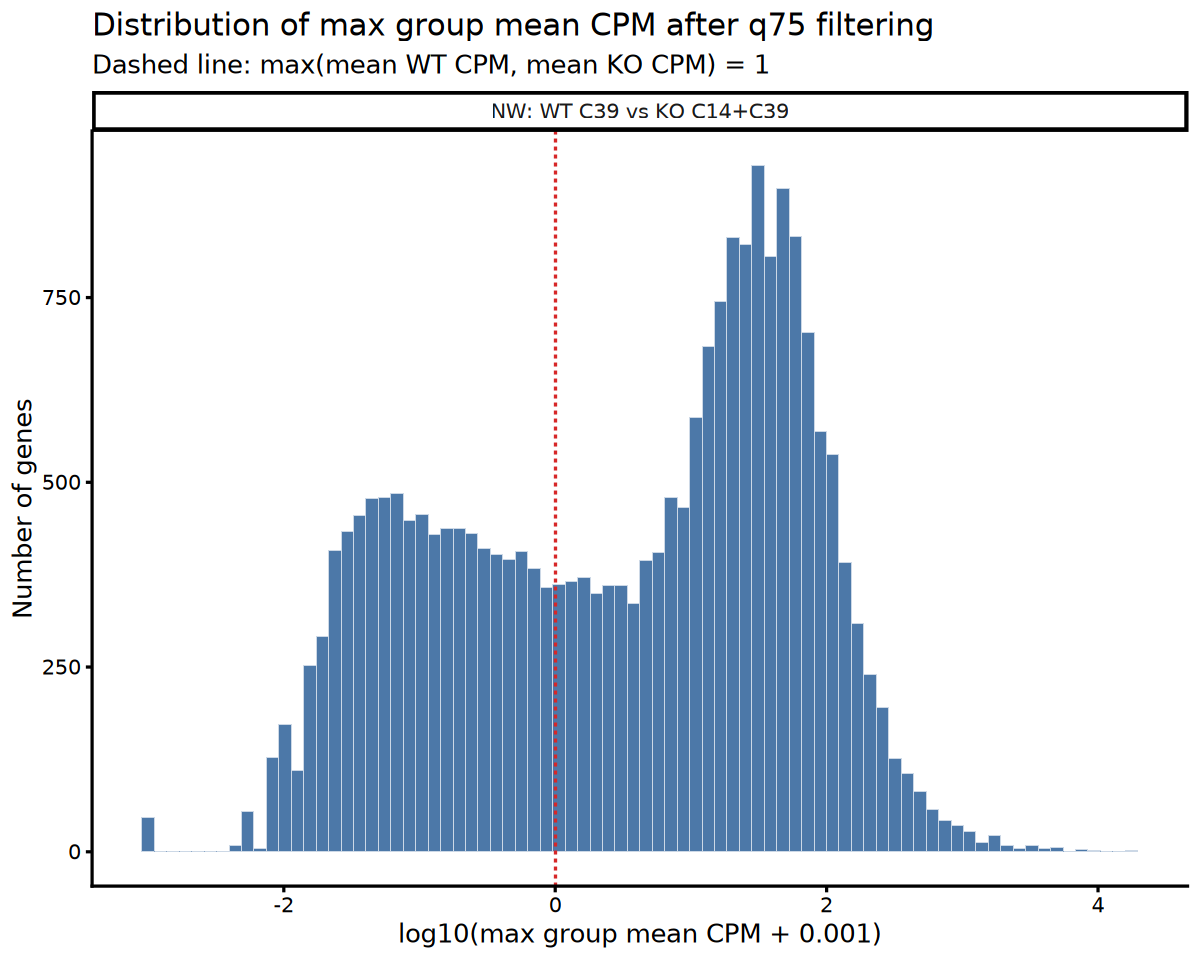

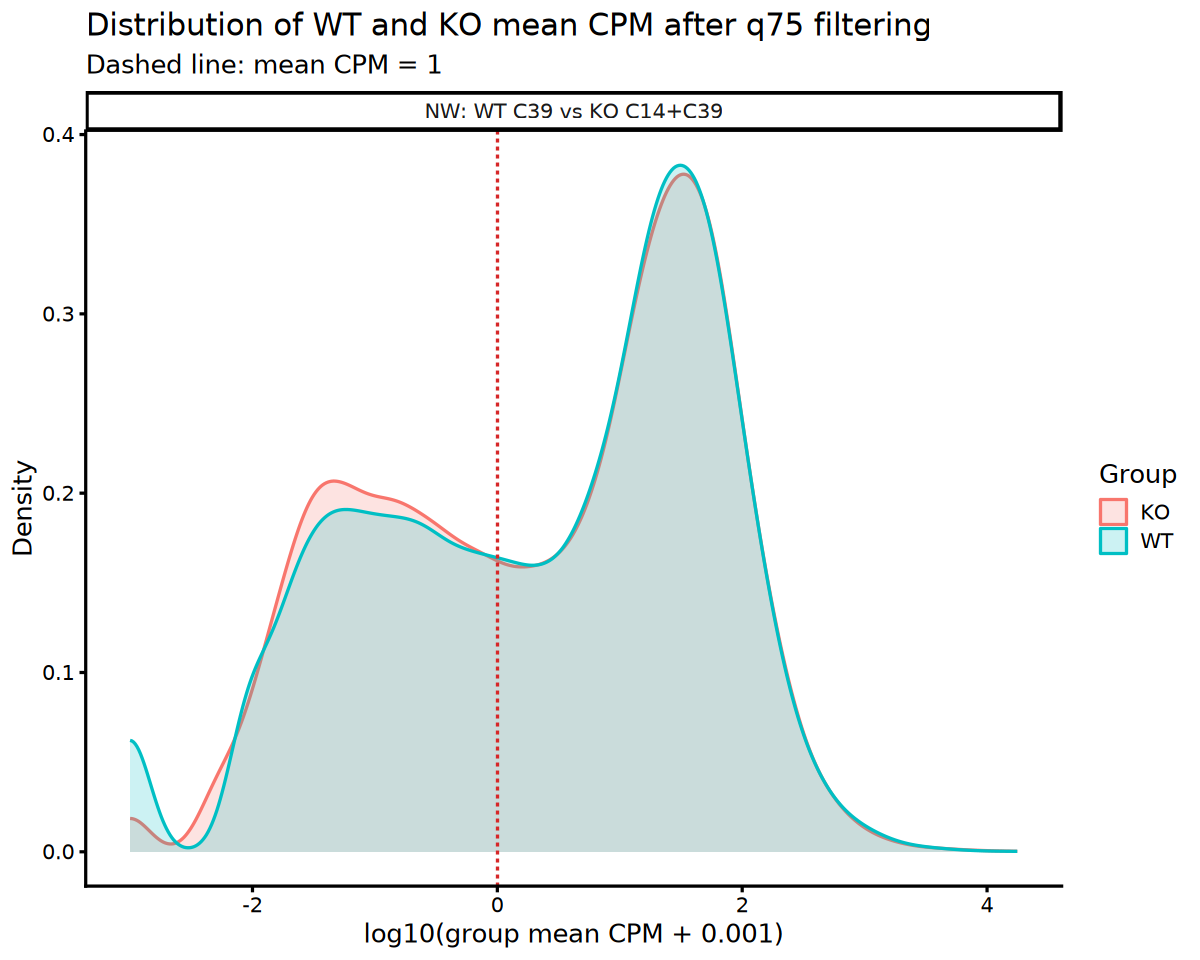

In [24]:
# Diagnostic: distribution of max(mean WT CPM, mean KO CPM) with and without q75 filtering.
# DE now uses the unfiltered annotated gene universe; q75 is shown only for comparison.
cpm_filter_min <- 1
cpm_plot_pseudocount <- 1e-3

mean_cpm_filter_comparisons <- tibble(
  comparison = "NW: WT C39 vs KO C14+C39",
  wt_conditions = list("NW_C39_DMSO"),
  ko_conditions = list(c("NW_C14_AUXIN", "NW_C39_AUXIN"))
)

make_mean_cpm_filter_diagnostic <- function(
    comparison,
    wt_conditions,
    ko_conditions,
    counts_source,
    filter_stage
) {
  conditions <- c(wt_conditions, ko_conditions)
  sample_idx <- which(meta$Dcondition %in% conditions)
  counts_sub <- counts_source[, sample_idx, drop = FALSE]
  meta_sub <- meta[sample_idx, , drop = FALSE]
  group <- factor(
    ifelse(meta_sub$Dcondition %in% ko_conditions, "KO", "WT"),
    levels = c("WT", "KO")
  )

  group_mean_cpm_metrics(counts_sub, group) %>%
    mutate(
      comparison = comparison,
      filter_stage = filter_stage,
      passes_cpm_filter = max_mean_CPM >= cpm_filter_min,
      .before = gene_id
    )
}

mean_cpm_filter_values_by_stage <- bind_rows(
  purrr::pmap_dfr(
    mean_cpm_filter_comparisons,
    function(comparison, wt_conditions, ko_conditions) {
      make_mean_cpm_filter_diagnostic(
        comparison,
        wt_conditions,
        ko_conditions,
        counts_source = cts_dat_before_q75,
        filter_stage = "DE input (no q75)"
      )
    }
  ),
  purrr::pmap_dfr(
    mean_cpm_filter_comparisons,
    function(comparison, wt_conditions, ko_conditions) {
      make_mean_cpm_filter_diagnostic(
        comparison,
        wt_conditions,
        ko_conditions,
        counts_source = cts_dat_q75,
        filter_stage = "q75 subset"
      )
    }
  )
)

mean_cpm_filter_values <- mean_cpm_filter_values_by_stage %>%
  filter(filter_stage == "DE input (no q75)")

mean_cpm_filter_summary <- mean_cpm_filter_values_by_stage %>%
  mutate(filter_stage = factor(filter_stage, levels = c("DE input (no q75)", "q75 subset"))) %>%
  group_by(comparison, filter_stage) %>%
  summarise(
    n_genes = n(),
    n_pass_cpm_0_1 = sum(max_mean_CPM >= 0.1, na.rm = TRUE),
    n_pass_cpm_0_5 = sum(max_mean_CPM >= 0.5, na.rm = TRUE),
    n_pass_cpm_1 = sum(max_mean_CPM >= 1, na.rm = TRUE),
    n_pass_cpm_2 = sum(max_mean_CPM >= 2, na.rm = TRUE),
    pct_pass_cpm_1 = round(100 * n_pass_cpm_1 / n_genes, 1),
    median_max_mean_CPM = median(max_mean_CPM, na.rm = TRUE),
    p25_max_mean_CPM = quantile(max_mean_CPM, 0.25, na.rm = TRUE),
    p75_max_mean_CPM = quantile(max_mean_CPM, 0.75, na.rm = TRUE),
    p90_max_mean_CPM = quantile(max_mean_CPM, 0.90, na.rm = TRUE),
    .groups = "drop"
  )

mean_cpm_filter_summary

p_max_mean_cpm_distribution <- mean_cpm_filter_values %>%
  ggplot(aes(x = log10(max_mean_CPM + cpm_plot_pseudocount))) +
  geom_histogram(bins = 80, fill = "#4C78A8", color = "white", linewidth = 0.15) +
  geom_vline(
    xintercept = log10(cpm_filter_min + cpm_plot_pseudocount),
    linetype = "dashed",
    color = "#D62728",
    linewidth = 0.7
  ) +
  facet_wrap(~ comparison, scales = "free_y") +
  labs(
    title = "Distribution of max group mean CPM in DE input",
    subtitle = "Dashed line: max(mean WT CPM, mean KO CPM) = 1",
    x = "log10(max group mean CPM + 0.001)",
    y = "Number of genes"
  )

p_group_mean_cpm_distribution <- mean_cpm_filter_values %>%
  select(comparison, gene_id, starts_with("mean_CPM_")) %>%
  pivot_longer(
    starts_with("mean_CPM_"),
    names_to = "group",
    values_to = "mean_CPM",
    names_prefix = "mean_CPM_"
  ) %>%
  ggplot(aes(x = log10(mean_CPM + cpm_plot_pseudocount), color = group, fill = group)) +
  geom_density(alpha = 0.2, linewidth = 0.7) +
  geom_vline(
    xintercept = log10(cpm_filter_min + cpm_plot_pseudocount),
    linetype = "dashed",
    color = "#D62728",
    linewidth = 0.7
  ) +
  facet_wrap(~ comparison, scales = "free_y") +
  labs(
    title = "Distribution of WT and KO mean CPM in DE input",
    subtitle = "Dashed line: mean CPM = 1",
    x = "log10(group mean CPM + 0.001)",
    y = "Density",
    color = "Group",
    fill = "Group"
  )

p_max_mean_cpm_distribution
p_group_mean_cpm_distribution


### Differential expression


contrast,n_tested,n_significant,n_up_in_KO,n_down_in_KO
<chr>,<int>,<int>,<int>,<int>
WT C14+C39 vs KO C14+C39,14648,4,0,4
WT C39 vs KO C14+C39,14805,58,15,43
WT C39 vs KO C39,14840,9,4,5


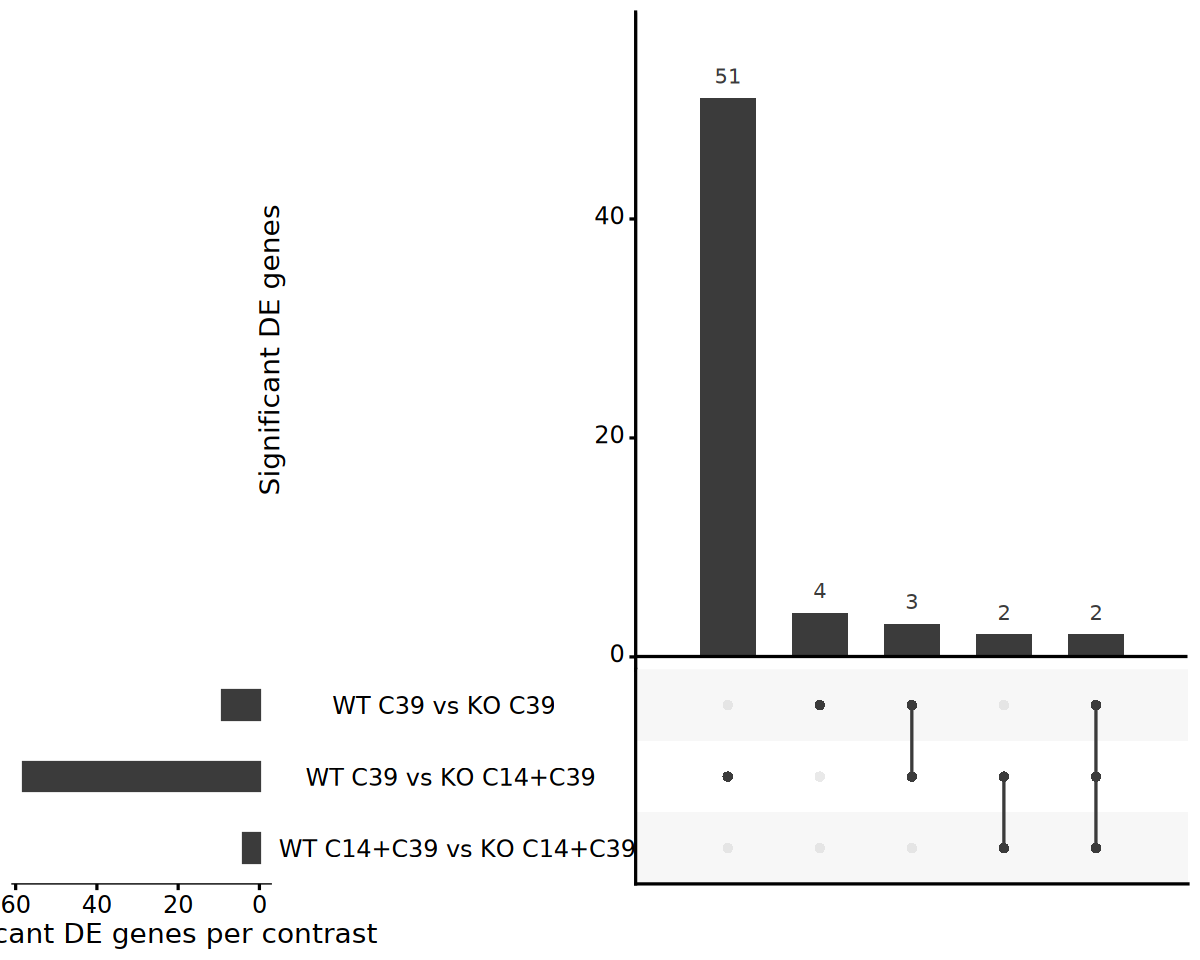

In [47]:
# NW degron sensitivity analysis. All logFC values are KO - WT,
# matching the existing DE notebooks. This cell creates in-memory results only.

run_nw_ko_vs_wt <- function(wt_conditions, ko_conditions, adjust_clone = FALSE) {
  conditions <- c(wt_conditions, ko_conditions)
  sample2keep <- which(meta$Dcondition %in% conditions)
  counts <- cts_dat[, sample2keep, drop = FALSE]
  colData <- meta[sample2keep, , drop = FALSE]
  rownames(colData) <- colnames(counts)
  stopifnot(
    all(colnames(counts) == rownames(colData)),
    all(conditions %in% colData$Dcondition)
  )
  
  group <- factor(
    ifelse(colData$Dcondition %in% ko_conditions, "KO", "WT"),
    levels = c("WT", "KO")
  )
  
  stopifnot(all(table(group) > 0))
  design <- model.matrix(~ 0 + group)
  colnames(design) <- c("WT", "KO")
  contrast <- makeContrasts(KOvsWT = KO - WT, levels = design)
  clone <- NULL
  if (all(grepl("^NW_(C14|C39)_(AUXIN|DMSO)$", colData$Dcondition))) {
    clone <- factor(sub("^NW_(C14|C39)_(AUXIN|DMSO)$", "\\1", colData$Dcondition))
    if (adjust_clone) {
      stopifnot(all(table(clone, group) > 0))
    }
  }
  
  y <- DGEList(counts)
  y <- calcNormFactors(y)
  fit <- fit_limma_with_optional_duplicate_correlation(y, design, block = clone, fit_label = "NW")
  fit <- eBayes(contrasts.fit(fit, contrast))
  tt <- topTable(fit, coef = "KOvsWT", number = Inf)
  filter_results_by_group_mean_cpm(tt, counts, group, min_cpm = 1)
}

wt_c14_c39 <- c("NW_C14_DMSO", "NW_C39_DMSO")
ko_c14_c39 <- c("NW_C14_AUXIN", "NW_C39_AUXIN")
wt_c39 <- "NW_C39_DMSO"
ko_c39 <- "NW_C39_AUXIN"

nw_de_results <- list(
  "WT C14+C39 vs KO C14+C39" = run_nw_ko_vs_wt(
    wt_c14_c39, ko_c14_c39, adjust_clone = TRUE
  ),
  "WT C39 vs KO C14+C39" = run_nw_ko_vs_wt(
    wt_c39, ko_c14_c39
  ),
  "WT C39 vs KO C39" = run_nw_ko_vs_wt(
    wt_c39, ko_c39
  )
)

ttNW_C14_C39 <- nw_de_results[["WT C14+C39 vs KO C14+C39"]]
ttNW_C39_WT_vs_C14_C39_KO <- nw_de_results[["WT C39 vs KO C14+C39"]]
ttNW_C39 <- nw_de_results[["WT C39 vs KO C39"]]

nw_de_summary <- imap_dfr(nw_de_results, function(result, contrast_name) {
  tibble(
    contrast = contrast_name,
    n_tested = nrow(result),
    n_significant = sum(result$threshold, na.rm = TRUE),
    n_up_in_KO = sum(result$threshold & result$logFC > 0, na.rm = TRUE),
    n_down_in_KO = sum(result$threshold & result$logFC < 0, na.rm = TRUE)
  )
})

nw_de_sets <- imap(nw_de_results, function(result, contrast_name) {
  rownames(result)[result$threshold]
})

nw_de_summary
options(
    repr.plot.width = 10,
    repr.plot.height = 8
  )
UpSetR::upset(
  UpSetR::fromList(nw_de_sets), text.scale = c(2, 2, 2, 2, 2, 2),
  sets = names(nw_de_sets),
  keep.order = TRUE,
  order.by = "freq",
  mainbar.y.label = "Significant DE genes",
  sets.x.label = "Significant DE genes per contrast"
)


In [48]:
ttNW_C39 <- ttNW_C39[order(ttNW_C39$adj.P.Val), , drop = FALSE]
ttNW_C39$ensembl_gene_id <- rownames(ttNW_C39)
ttNW_C39$hgnc_symbol <- gene_anno$hgnc_symbol[
  match(ttNW_C39$ensembl_gene_id, gene_anno$ensembl_gene_id)
]
ttNW_C39$gene_label <- ifelse(
  is.na(ttNW_C39$hgnc_symbol) | ttNW_C39$hgnc_symbol == "",
  ttNW_C39$ensembl_gene_id,
  ttNW_C39$hgnc_symbol
)
rownames(ttNW_C39) <- make.unique(ttNW_C39$gene_label)

In [49]:
ttNW_C39

,logFC,AveExpr,t,P.Value,adj.P.Val,B,ensembl_gene_id,hgnc_symbol,gene_label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
HHIP,5.5401439,3.687992,22.493131,2.137398e-07,0.002326382,5.7153403,ENSG00000164161,HHIP,HHIP
F8A2,9.2868329,-1.664191,21.187258,3.135286e-07,0.002326382,1.4142931,ENSG00000288709,F8A2,F8A2
F8A3,-9.2366669,-1.724757,-19.379936,5.544374e-07,0.002742617,1.3496879,ENSG00000277150,F8A3,F8A3
MYH3,2.6759264,2.745466,14.137622,4.106003e-06,0.015233270,4.4336284,ENSG00000109063,MYH3,MYH3
SERPINI1,-1.9581274,3.104412,-12.080321,1.101085e-05,0.032680201,3.9227244,ENSG00000163536,SERPINI1,SERPINI1
NKX2-6,-1.9035356,3.421824,-11.269377,1.696676e-05,0.036684519,3.6337178,ENSG00000180053,NKX2-6,NKX2-6
DKK2,3.9225925,2.670358,11.233679,1.730402e-05,0.036684519,3.2268987,ENSG00000155011,DKK2,DKK2
RSPO3,-3.6362109,4.801605,-10.916243,2.066660e-05,0.038336542,3.5269090,ENSG00000146374,RSPO3,RSPO3
PRDM6,-2.3825520,1.491905,-10.293443,2.969513e-05,0.048963968,2.5733278,ENSG00000061455,PRDM6,PRDM6


In [50]:
# DESeq2 differential expression for C39 only (KO - WT)
# Results remain in memory and are not written to disk.

c39_conditions <- c("NW_C39_DMSO", "NW_C39_AUXIN")
c39_samples <- which(meta$Dcondition %in% c39_conditions)
c39_counts <- as.matrix(cts_dat[, c39_samples, drop = FALSE])
c39_coldata <- meta[c39_samples, , drop = FALSE]
rownames(c39_coldata) <- colnames(c39_counts)

stopifnot(
  all(colnames(c39_counts) == rownames(c39_coldata)),
  all(c39_conditions %in% c39_coldata$Dcondition),
  all(c39_counts == round(c39_counts))
)

c39_coldata$condition <- factor(
  ifelse(c39_coldata$Dcondition == "NW_C39_AUXIN", "KO", "WT"),
  levels = c("WT", "KO")
)
c39_design <- model.matrix(~ 0 + condition, data = c39_coldata)
colnames(c39_design) <- c("WT", "KO")
storage.mode(c39_counts) <- "integer"

dds_C39 <- DESeq2::DESeqDataSetFromMatrix(
  countData = c39_counts,
  colData = c39_coldata,
  design = ~ condition
)
dds_C39 <- DESeq2::DESeq(dds_C39)

resDESeq2_C39 <- as.data.frame(
  DESeq2::results(
    dds_C39,
    contrast = c("condition", "KO", "WT"),
    independentFiltering = FALSE
  )
)
resDESeq2_C39$ensembl_gene_id <- rownames(resDESeq2_C39)
resDESeq2_C39$hgnc_symbol <- gene_anno$hgnc_symbol[
  match(resDESeq2_C39$ensembl_gene_id, gene_anno$ensembl_gene_id)
]
resDESeq2_C39$gene_label <- ifelse(
  is.na(resDESeq2_C39$hgnc_symbol) | resDESeq2_C39$hgnc_symbol == "",
  resDESeq2_C39$ensembl_gene_id,
  resDESeq2_C39$hgnc_symbol
)
resDESeq2_C39 <- filter_results_by_group_mean_cpm(
  resDESeq2_C39,
  c39_counts,
  c39_coldata$condition,
  min_cpm = 1,
  gene_col = "ensembl_gene_id"
)
resDESeq2_C39 <- resDESeq2_C39[order(resDESeq2_C39$padj, na.last = TRUE), ]

resDESeq2_C39

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,ensembl_gene_id,hgnc_symbol,gene_label
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
ENSG00000164161,1794.26362,5.5016724,0.2373590,23.178698,7.468738e-119,1.107838e-114,ENSG00000164161,HHIP,HHIP
ENSG00000109063,392.11251,2.6561045,0.2007284,13.232329,5.709029e-40,4.234101e-36,ENSG00000109063,MYH3,MYH3
ENSG00000155011,537.97193,3.9225636,0.2986881,13.132642,2.140570e-39,1.058369e-35,ENSG00000155011,DKK2,DKK2
ENSG00000154529,340.86006,3.5482287,0.2833552,12.522193,5.645379e-36,2.093448e-32,ENSG00000154529,CNTNAP3B,CNTNAP3B
ENSG00000146374,2221.55759,-3.6747896,0.3276563,-11.215378,3.427183e-29,1.016708e-25,ENSG00000146374,RSPO3,RSPO3
ENSG00000163536,427.33238,-1.9459660,0.1778129,-10.943896,7.107823e-28,1.757172e-24,ENSG00000163536,SERPINI1,SERPINI1
ENSG00000121068,1061.61547,-2.9162308,0.2719364,-10.723945,7.857897e-27,1.665088e-23,ENSG00000121068,TBX2,TBX2
ENSG00000136535,171.89495,-4.8536295,0.4674301,-10.383648,2.943104e-25,5.456883e-22,ENSG00000136535,TBR1,TBR1
ENSG00000061455,154.15055,-2.3829756,0.2390502,-9.968514,2.093378e-23,3.450120e-20,ENSG00000061455,PRDM6,PRDM6


In [51]:
# Limma-voom C39-only DE using post-test CPM filtering.
# The contrast is KO - WT, and no files are written.

c39_y <- edgeR::DGEList(c39_counts)
c39_y <- edgeR::calcNormFactors(c39_y)
c39_voom <- limma::voom(c39_y, c39_design, plot = FALSE)
c39_fit <- limma::lmFit(c39_voom, c39_design)
c39_contrast <- limma::makeContrasts(KOvsWT = KO - WT, levels = c39_design)
c39_fit <- limma::eBayes(limma::contrasts.fit(c39_fit, c39_contrast))

ttLimma_C39_matched <- limma::topTable(
  c39_fit,
  coef = "KOvsWT",
  number = Inf,
  adjust.method = "BH"
)
ttLimma_C39_matched$ensembl_gene_id <- rownames(ttLimma_C39_matched)
ttLimma_C39_matched$hgnc_symbol <- gene_anno$hgnc_symbol[
  match(ttLimma_C39_matched$ensembl_gene_id, gene_anno$ensembl_gene_id)
]
ttLimma_C39_matched <- filter_results_by_group_mean_cpm(
  ttLimma_C39_matched,
  c39_counts,
  c39_coldata$condition,
  min_cpm = 1,
  gene_col = "ensembl_gene_id"
)

c39_method_comparison <- inner_join(
  tibble(
    ensembl_gene_id = ttLimma_C39_matched$ensembl_gene_id,
    logFC_limma = ttLimma_C39_matched$logFC,
    p_value_limma = ttLimma_C39_matched$P.Value,
    padj_limma = ttLimma_C39_matched$adj.P.Val
  ),
  tibble(
    ensembl_gene_id = resDESeq2_C39$ensembl_gene_id,
    logFC_deseq2 = resDESeq2_C39$log2FoldChange,
    p_value_deseq2 = resDESeq2_C39$pvalue,
    padj_deseq2 = resDESeq2_C39$padj
  ),
  by = "ensembl_gene_id"
) %>%
  mutate(
    DE_limma = padj_limma < 0.05 & abs(logFC_limma) >= 1,
    DE_deseq2 = padj_deseq2 < 0.05 & abs(logFC_deseq2) >= 1
  )

c39_method_comparison_summary <- c39_method_comparison %>%
  summarise(
    n_genes = n(),
    logFC_correlation = cor(logFC_limma, logFC_deseq2, use = "complete.obs"),
    n_DE_limma = sum(DE_limma, na.rm = TRUE),
    n_DE_deseq2 = sum(DE_deseq2, na.rm = TRUE),
    n_shared_DE = sum(DE_limma & DE_deseq2, na.rm = TRUE)
  )

c39_method_comparison_summary

n_genes,logFC_correlation,n_DE_limma,n_DE_deseq2,n_shared_DE
<int>,<dbl>,<int>,<int>,<int>
14840,0.9757651,9,442,9


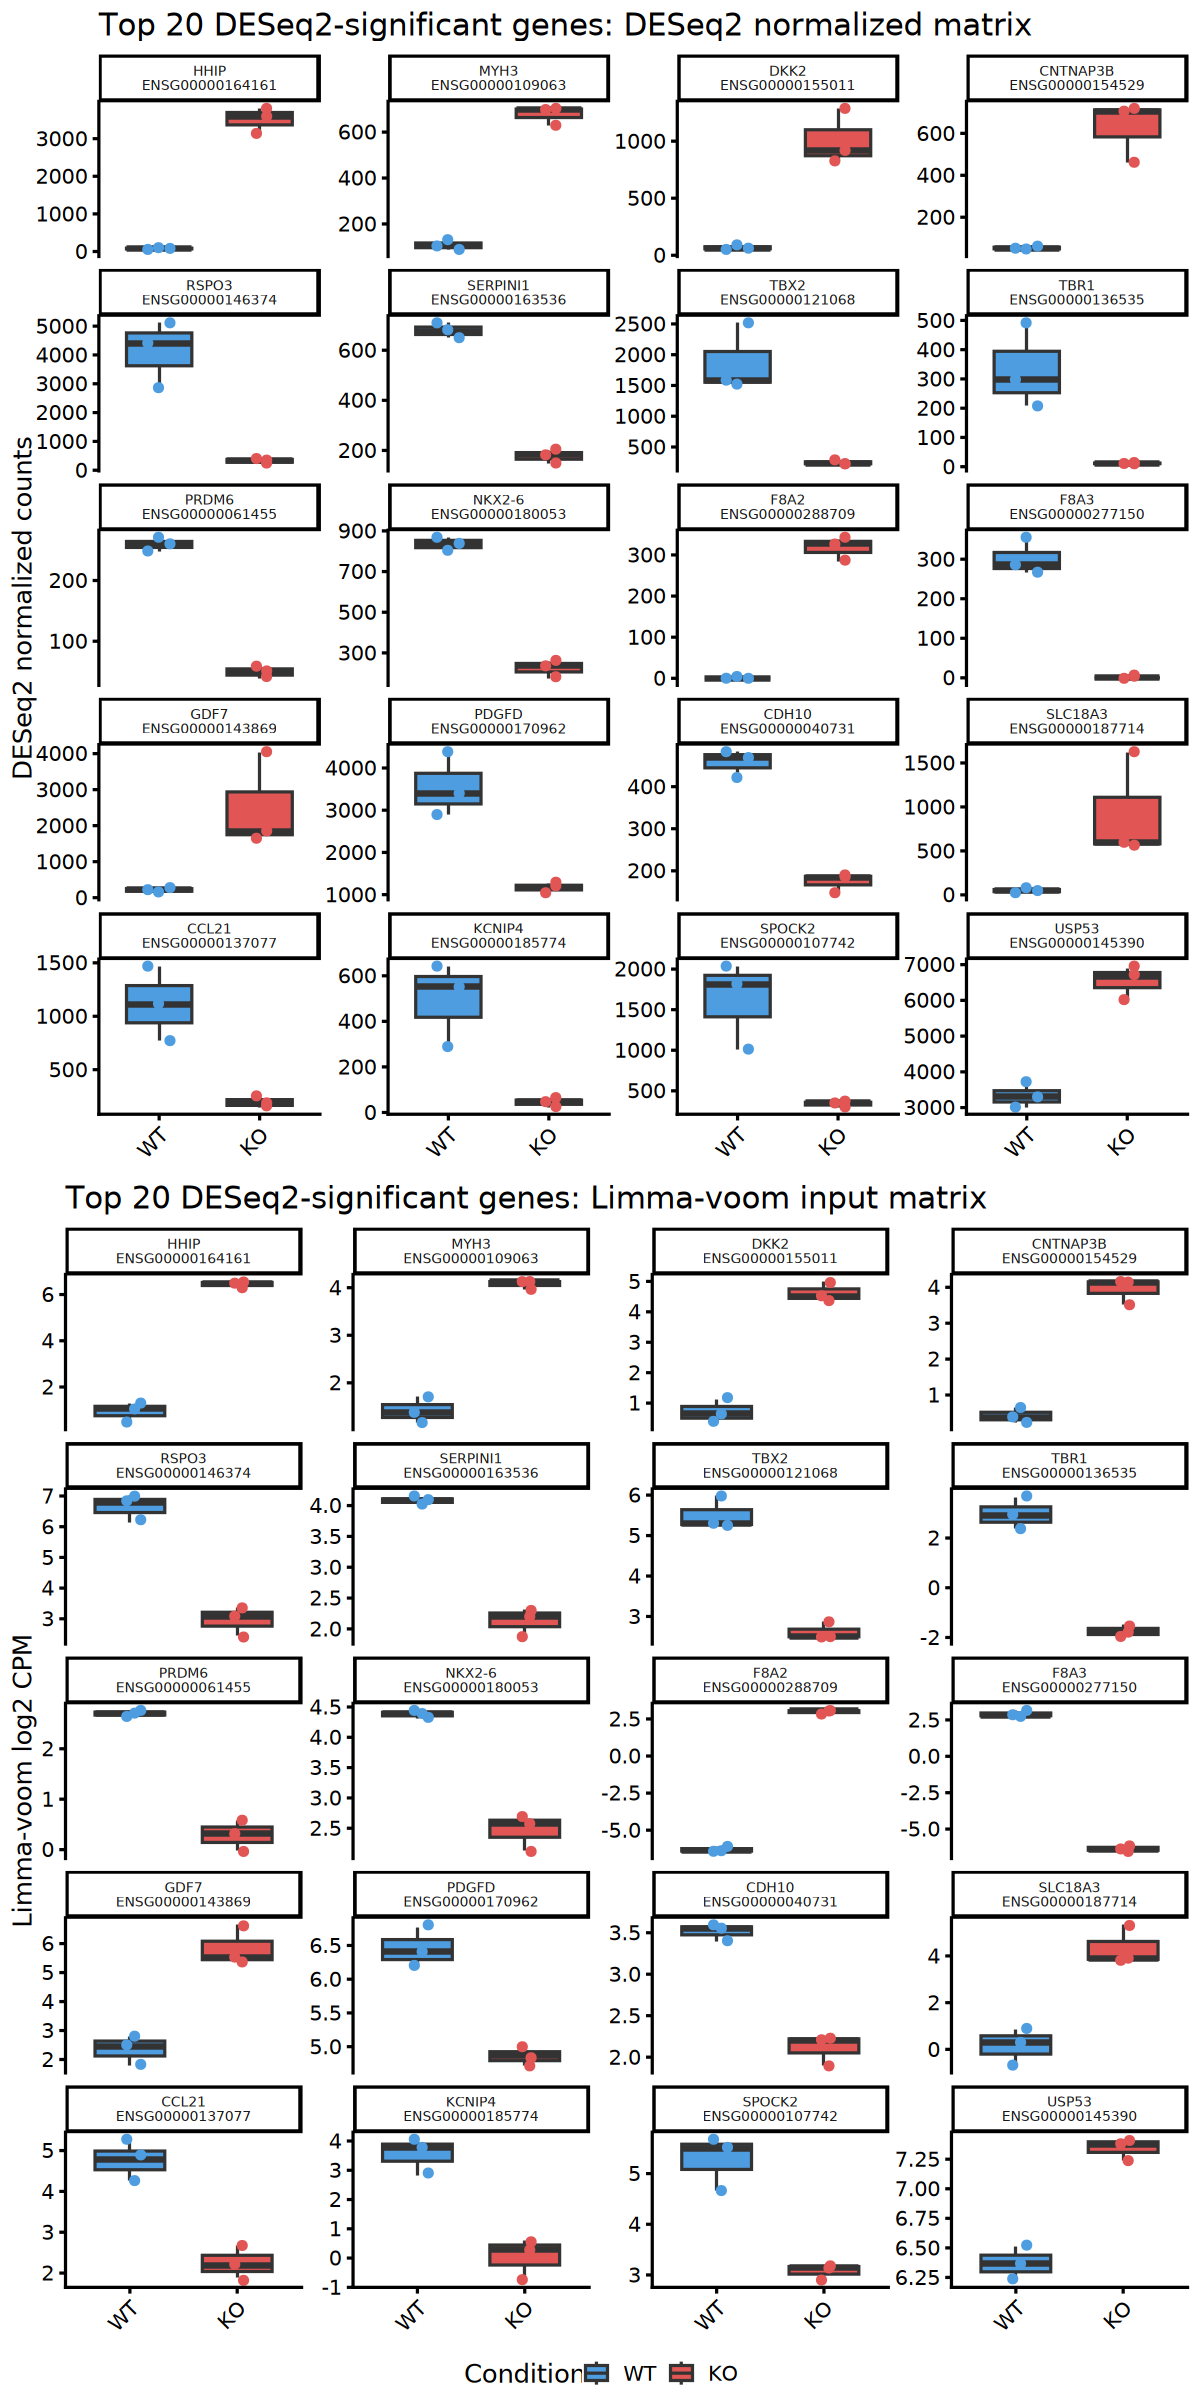

In [52]:
# Compare the normalized expression values used by DESeq2 and Limma-voom
# for the 20 most significant DESeq2 genes in the C39 KO-versus-WT contrast.
# DESeq2 is shown on its normalized-count scale; Limma-voom is shown on its
# log2 counts-per-million scale. The y-axis is free for each gene because
# expression ranges differ substantially across genes.

top20_deseq2 <- resDESeq2_C39 %>%
  filter(!is.na(padj), padj < 0.05) %>%
  arrange(padj) %>%
  slice_head(n = 20) %>%
  mutate(
    gene_panel = paste0(gene_label, "\n", ensembl_gene_id),
    gene_panel = factor(gene_panel, levels = gene_panel)
  )

top20_gene_ids <- top20_deseq2$ensembl_gene_id
stopifnot(
  length(top20_gene_ids) > 0,
  all(top20_gene_ids %in% rownames(DESeq2::counts(dds_C39, normalized = TRUE))),
  all(top20_gene_ids %in% rownames(c39_voom$E))
)

make_top20_expression_long <- function(expression_matrix, method) {
  as.data.frame(expression_matrix) %>%
    rownames_to_column("ensembl_gene_id") %>%
    pivot_longer(
      cols = -ensembl_gene_id,
      names_to = "sample",
      values_to = "expression"
    ) %>%
    left_join(
      c39_coldata %>%
        rownames_to_column("sample") %>%
        select(sample, condition),
      by = "sample"
    ) %>%
    left_join(
      top20_deseq2 %>% select(ensembl_gene_id, gene_panel),
      by = "ensembl_gene_id"
    ) %>%
    mutate(method = method)
}

plot_top20_expression <- function(expression_data, y_axis_label, title) {
  ggplot(expression_data, aes(x = condition, y = expression, fill = condition)) +
    geom_boxplot(width = 0.65, outlier.shape = NA) +
    geom_point(
      aes(color = condition),
      position = position_jitter(width = 0.12),
      size = 1.8,
      show.legend = FALSE
    ) +
    facet_wrap(~ gene_panel, ncol = 4, scales = "free_y") +
    scale_fill_manual(values = c(WT = "#4D9DE0", KO = "#E15554")) +
    scale_color_manual(values = c(WT = "#4D9DE0", KO = "#E15554")) +
    labs(
      title = title,
      x = NULL,
      y = y_axis_label,
      fill = "Condition"
    ) +
    theme(
      strip.text = element_text(size = 8),
      axis.text.x = element_text(angle = 45, hjust = 1)
    )
}

# DESeq2-normalized count matrix (the values underlying DESeq2 baseMean).
deseq2_top20_long <- make_top20_expression_long(
  DESeq2::counts(dds_C39, normalized = TRUE)[top20_gene_ids, , drop = FALSE],
  method = "DESeq2 normalized counts"
)

# Matrix used by limma after TMM normalization and voom transformation.
limma_top20_long <- make_top20_expression_long(
  c39_voom$E[top20_gene_ids, , drop = FALSE],
  method = "Limma-voom log2 CPM"
)

p_top20_deseq2_normalized <- plot_top20_expression(
  deseq2_top20_long,
  y_axis_label = "DESeq2 normalized counts",
  title = "Top 20 DESeq2-significant genes: DESeq2 normalized matrix"
)

p_top20_limma_voom <- plot_top20_expression(
  limma_top20_long,
  y_axis_label = "Limma-voom log2 CPM",
  title = "Top 20 DESeq2-significant genes: Limma-voom input matrix"
)

# Keep the two scales separate: normalized counts and log2 CPM are not
# directly comparable on one shared y-axis.
options(
    repr.plot.width = 10,
    repr.plot.height = 20
  )
ggpubr::ggarrange(
  p_top20_deseq2_normalized,
  p_top20_limma_voom,
  ncol = 1,
  common.legend = TRUE,
  legend = "bottom"
)


Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`).”


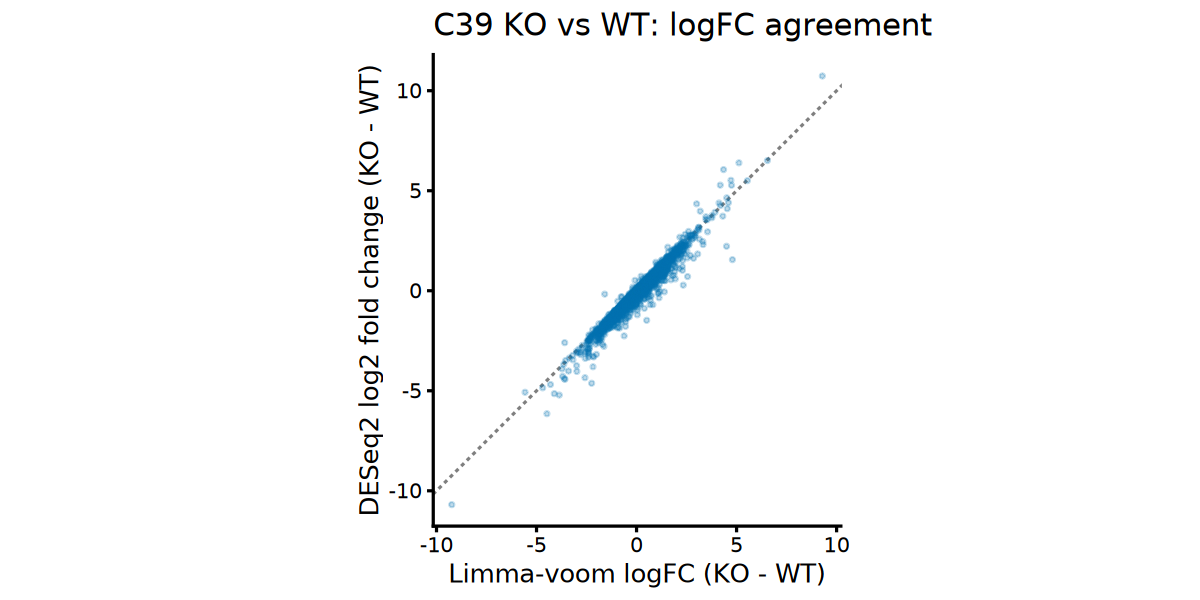

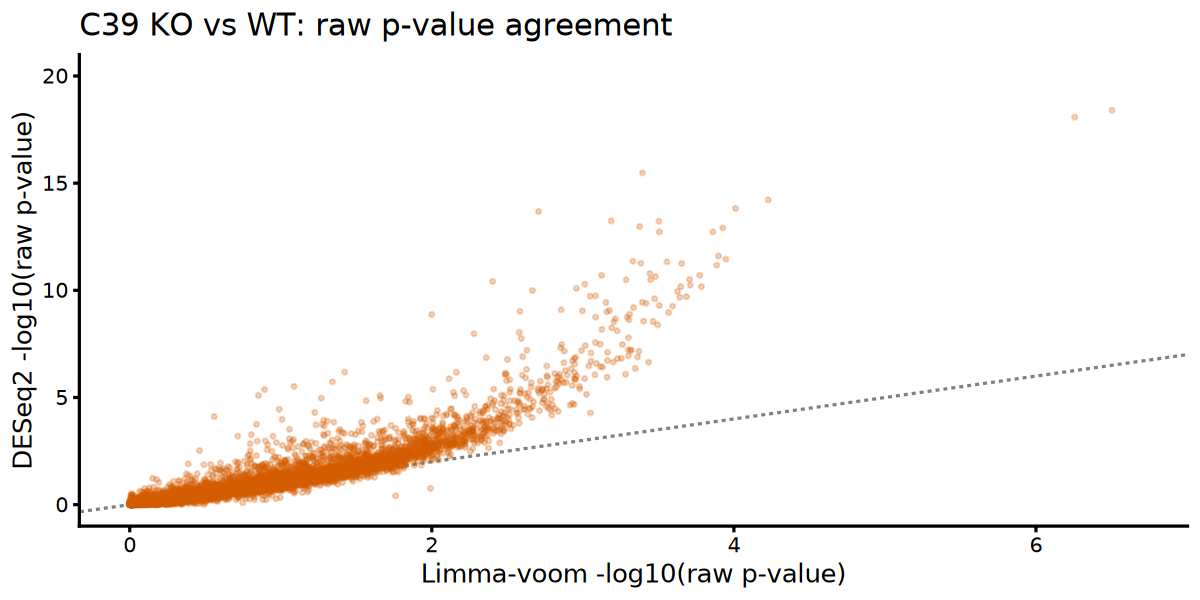

In [53]:
# Matched Limma-voom and DESeq2 C39-only results: effect sizes and raw p-values.
# No files are written.

c39_scatter_data <- c39_method_comparison %>%
  mutate(
    neg_log10_p_limma = -log10(pmax(p_value_limma, .Machine$double.xmin)),
    neg_log10_p_deseq2 = -log10(pmax(p_value_deseq2, .Machine$double.xmin))
  )

p_c39_logFC <- c39_scatter_data %>%
  filter(!is.na(logFC_limma), !is.na(logFC_deseq2)) %>%
  ggplot(aes(x = logFC_limma, y = logFC_deseq2)) + 
  geom_abline(slope = 1, intercept = 0, color = "grey50", linetype = "dashed") +
  geom_point(alpha = 0.25, size = 0.7, color = "#0072B2") +
  coord_equal() +
  labs(
    title = "C39 KO vs WT: logFC agreement",
    x = "Limma-voom logFC (KO - WT)",
    y = "DESeq2 log2 fold change (KO - WT)"
  ) +
  theme_classic(base_size = 15)

p_c39_pvalue <- c39_scatter_data %>%
  filter(!is.na(neg_log10_p_limma), !is.na(neg_log10_p_deseq2)) %>%
  ggplot(aes(x = neg_log10_p_limma, y = neg_log10_p_deseq2)) + ylim(0, 20) +
  geom_abline(slope = 1, intercept = 0, color = "grey50", linetype = "dashed") +
  geom_point(alpha = 0.25, size = 0.7, color = "#D55E00") +
  labs(
    title = "C39 KO vs WT: raw p-value agreement",
    x = "Limma-voom -log10(raw p-value)",
    y = "DESeq2 -log10(raw p-value)"
  ) +
  theme_classic(base_size = 15)

options(
    repr.plot.width = 10,
    repr.plot.height = 5
  )
p_c39_logFC
p_c39_pvalue

In [54]:
# # Is the Normal-versus-t reference distribution responsible for the raw-p gap?
# #
# # For the same absolute statistic, a Student t distribution has heavier tails
# # than a standard Normal distribution. Therefore its two-sided p-value is larger.
# # Limma uses a moderated t with empirical-Bayes total degrees of freedom
# # (df.total), rather than the unmoderated residual df of 4 from 3 WT + 3 KO.
# # As df.total increases, the t distribution approaches the Normal distribution.

# c39_reference_distribution <- c39_test_comparison %>%
#   filter(
#     is.finite(limma_moderated_t),
#     is.finite(limma_total_df),
#     limma_total_df > 0,
#     is.finite(p_value_limma)
#   ) %>%
#   mutate(
#     # Counterfactual: Limma's observed t statistic evaluated against Normal.
#     limma_p_if_normal = 2 * pnorm(-abs(limma_moderated_t)),
#     # Validation: the moderated-t p-value reconstructed from Limma's t and df.
#     limma_p_recomputed_t = 2 * pt(-abs(limma_moderated_t), df = limma_total_df),
#     # Positive values mean the t reference made Limma's p-value less significant.
#     delta_neg_log10_p_t_vs_normal =
#       -log10(pmax(limma_p_if_normal, .Machine$double.xmin)) -
#       -log10(pmax(p_value_limma, .Machine$double.xmin))
#   )

# # This reports the actual degrees of freedom and the p-value shift caused solely
# # by using a t rather than Normal reference for the same Limma statistic.
# c39_reference_distribution_summary <- c39_reference_distribution %>%
#   group_by(significance_pattern) %>%
#   summarise(
#     n_genes = n(),
#     median_limma_total_df = median(limma_total_df),
#     median_t_vs_normal_delta_all = median(delta_neg_log10_p_t_vs_normal),
#     median_t_vs_normal_delta_abs_t_ge_3 = median(
#       delta_neg_log10_p_t_vs_normal[abs(limma_moderated_t) >= 3],
#       na.rm = TRUE
#     ),
#     max_t_vs_normal_delta = max(delta_neg_log10_p_t_vs_normal),
#     .groups = "drop"
#   )

# c39_reference_distribution_summary

# # Compare Limma's moderated-t p-value with the p-value obtained by evaluating
# # that exact same t statistic against a Normal reference. The dashed y = x line
# # marks no effect of the reference distribution.
# p_c39_t_vs_normal_reference <- c39_reference_distribution %>%
#   mutate(
#     neg_log10_p_limma_t = -log10(pmax(p_value_limma, .Machine$double.xmin)),
#     neg_log10_p_limma_if_normal = -log10(pmax(limma_p_if_normal, .Machine$double.xmin))
#   ) %>%
#   ggplot(
#     aes(
#       x = neg_log10_p_limma_t,
#       y = neg_log10_p_limma_if_normal,
#       color = significance_pattern
#     )
#   ) +
#   geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
#   geom_point(alpha = 0.35, size = 0.9) +
#   scale_color_manual(
#     values = c(
#       "Both significant" = "#6A3D9A",
#       "DESeq2 only" = "#E31A1C",
#       "Limma only" = "#1F78B4",
#       "Neither significant" = "grey75"
#     )
#   ) +
#   labs(
#     title = "C39: Limma moderated-t versus Normal-reference p-values",
#     x = "Limma moderated-t -log10(raw p-value)",
#     y = "Same Limma t statistic evaluated as Normal: -log10(raw p-value)",
#     color = "Significance call"
#   )

# p_c39_t_vs_normal_reference

# # Check that the reconstructed t p-values agree with Limma's reported p-values.
# c39_reference_distribution %>%
#   summarise(
#     max_abs_difference_reported_vs_recomputed_limma_p = max(
#       abs(p_value_limma - limma_p_recomputed_t),
#       na.rm = TRUE
#     )
#   )


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



method,n_input_samples,n_genes_after_filter,n_genes_tested,n_significant,n_shared_significant,logFC_correlation,test_statistic_correlation
<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>
DESeq2,18,14333,14331,1023,1009,0.9334871,0.9975414
Limma-voom,18,14333,14333,1031,1009,0.9334871,0.9975414


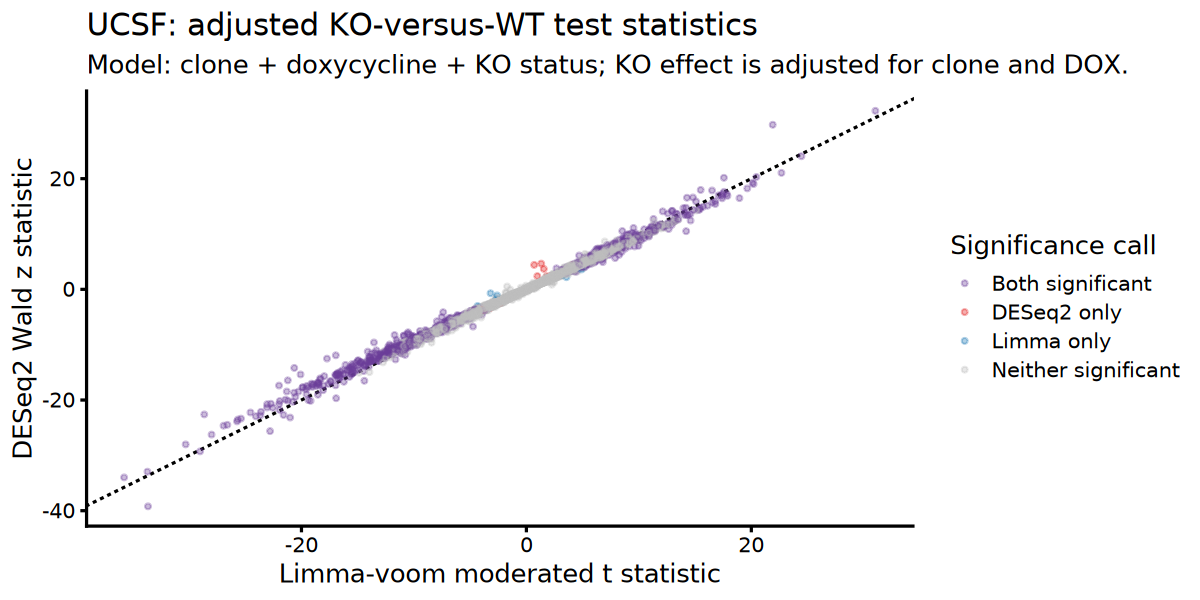

In [55]:
# UCSF KO-versus-WT comparison: DESeq2 versus Limma-voom
#
# The model uses KO status as the only fixed effect.
# Limma-voom uses clone as a duplicate-correlation block when enough clone
# blocks are available; DESeq2 uses the matching group-only design.

ucsf_conditions <- c(
  "UCSF_AAVS1_DMSO",
  "UCSF_AAVS1_DOX",
  "UCSF_CLONE_D1_DMSO",
  "UCSF_CLONE_D1_DOX",
  "UCSF_CLONE_B1 DMSO",
  "UCSF_CLONE_B1 DOX"
)

ucsf_samples <- which(meta$Dcondition %in% ucsf_conditions)
ucsf_counts <- as.matrix(cts_dat[, ucsf_samples, drop = FALSE])
ucsf_coldata <- meta[ucsf_samples, , drop = FALSE]
rownames(ucsf_coldata) <- colnames(ucsf_counts)

ucsf_coldata$clone <- factor(
  sub(
    "^UCSF_(CLONE_)?(D1|B1|AAVS1)[_ ](DMSO|DOX)$",
    "\\2",
    ucsf_coldata$Dcondition
  ),
  levels = c("AAVS1", "D1", "B1")
)
ucsf_coldata$doxycycline <- factor(
  ifelse(grepl("DOX$", ucsf_coldata$Dcondition), "DOX", "DMSO"),
  levels = c("DMSO", "DOX")
)
ucsf_coldata$ko_status <- factor(ucsf_coldata$ko_gene, levels = c("WT", "KO"))

stopifnot(
  all(colnames(ucsf_counts) == rownames(ucsf_coldata)),
  all(ucsf_coldata$Dcondition %in% ucsf_conditions),
  all(!is.na(ucsf_coldata$clone)),
  all(table(ucsf_coldata$ko_status) > 0),
  all(ucsf_counts == round(ucsf_counts))
)

# Fit q75-passing genes first, then mark/apply max(mean WT CPM, mean KO CPM) >= 1 in results.
ucsf_design <- model.matrix(~ 0 + ko_status, data = ucsf_coldata)
colnames(ucsf_design) <- c("WT", "KO")
ucsf_ko_contrast <- limma::makeContrasts(KOvsWT = KO - WT, levels = ucsf_design)

ucsf_y <- edgeR::DGEList(ucsf_counts)

# DESeq2: negative-binomial GLM and Wald test for the group-only KO coefficient.
storage.mode(ucsf_counts) <- "integer"
dds_UCSF <- DESeq2::DESeqDataSetFromMatrix(
  countData = ucsf_counts,
  colData = ucsf_coldata,
  design = ~ ko_status
)
dds_UCSF <- DESeq2::DESeq(dds_UCSF)

resDESeq2_UCSF <- as.data.frame(
  DESeq2::results(
    dds_UCSF,
    contrast = c("ko_status", "KO", "WT"),
    independentFiltering = FALSE
  )
)
resDESeq2_UCSF$ensembl_gene_id <- rownames(resDESeq2_UCSF)
resDESeq2_UCSF$hgnc_symbol <- gene_anno$hgnc_symbol[
  match(resDESeq2_UCSF$ensembl_gene_id, gene_anno$ensembl_gene_id)
]
resDESeq2_UCSF$gene_label <- ifelse(
  is.na(resDESeq2_UCSF$hgnc_symbol) | resDESeq2_UCSF$hgnc_symbol == "",
  resDESeq2_UCSF$ensembl_gene_id,
  resDESeq2_UCSF$hgnc_symbol
)
resDESeq2_UCSF <- filter_results_by_group_mean_cpm(
  resDESeq2_UCSF,
  ucsf_counts,
  ucsf_coldata$ko_status,
  min_cpm = 1,
  gene_col = "ensembl_gene_id"
)

# Limma-voom: TMM normalization, precision-weighted linear model, moderated t.
ucsf_y <- edgeR::calcNormFactors(ucsf_y)
ucsf_voom <- limma::voom(ucsf_y, ucsf_design, plot = FALSE)
ucsf_fit <- fit_limma_with_optional_duplicate_correlation(
  ucsf_y,
  ucsf_design,
  block = ucsf_coldata$clone,
  fit_label = "UCSF"
)
ucsf_fit <- limma::eBayes(limma::contrasts.fit(ucsf_fit, ucsf_ko_contrast))

ttLimma_UCSF <- limma::topTable(
  ucsf_fit,
  coef = "KOvsWT",
  number = Inf,
  adjust.method = "BH",
  sort.by = "none"
)
ttLimma_UCSF$ensembl_gene_id <- rownames(ttLimma_UCSF)
ttLimma_UCSF$lfc_se_limma <- sqrt(ucsf_fit$s2.post) * ucsf_fit$stdev.unscaled[, "KOvsWT"]
ttLimma_UCSF <- filter_results_by_group_mean_cpm(
  ttLimma_UCSF,
  ucsf_counts,
  ucsf_coldata$ko_status,
  min_cpm = 1,
  gene_col = "ensembl_gene_id"
)

ucsf_method_comparison <- inner_join(
  resDESeq2_UCSF %>%
    transmute(
      ensembl_gene_id,
      gene_label,
      logFC_deseq2 = log2FoldChange,
      lfc_se_deseq2 = lfcSE,
      p_value_deseq2 = pvalue,
      padj_deseq2 = padj
    ),
  ttLimma_UCSF %>%
    transmute(
      ensembl_gene_id,
      logFC_limma = logFC,
      lfc_se_limma,
      limma_moderated_t = t,
      p_value_limma = P.Value,
      padj_limma = adj.P.Val
    ),
  by = "ensembl_gene_id"
) %>%
  mutate(
    deseq2_wald_z = logFC_deseq2 / lfc_se_deseq2,
    DE_deseq2 = padj_deseq2 < 0.05 & abs(logFC_deseq2) >= 1,
    DE_limma = padj_limma < 0.05 & abs(logFC_limma) >= 1,
    significance_pattern = case_when(
      DE_deseq2 & DE_limma ~ "Both significant",
      DE_deseq2 ~ "DESeq2 only",
      DE_limma ~ "Limma only",
      TRUE ~ "Neither significant"
    ),
    significance_pattern = factor(
      significance_pattern,
      levels = c("Both significant", "DESeq2 only", "Limma only", "Neither significant")
    )
  )

# Number of genes retained/tested and final significant calls (FDR < 0.05,
# absolute log2 fold change >= 1) for each method.
ucsf_de_summary <- tibble(
  method = c("DESeq2", "Limma-voom"),
  n_input_samples = ncol(ucsf_counts),
  n_genes_after_filter = c(nrow(resDESeq2_UCSF), nrow(ttLimma_UCSF)),
  n_genes_tested = c(
    sum(!is.na(resDESeq2_UCSF$pvalue)),
    sum(!is.na(ttLimma_UCSF$P.Value))
  ),
  n_significant = c(
    sum(ucsf_method_comparison$DE_deseq2, na.rm = TRUE),
    sum(ucsf_method_comparison$DE_limma, na.rm = TRUE)
  ),
  n_shared_significant = sum(
    ucsf_method_comparison$DE_deseq2 & ucsf_method_comparison$DE_limma,
    na.rm = TRUE
  ),
  logFC_correlation = cor(
    ucsf_method_comparison$logFC_deseq2,
    ucsf_method_comparison$logFC_limma,
    use = "complete.obs"
  ),
  test_statistic_correlation = cor(
    ucsf_method_comparison$deseq2_wald_z,
    ucsf_method_comparison$limma_moderated_t,
    use = "complete.obs"
  )
)

ucsf_de_summary

# Direct comparison of the methods' gene-level evidence. The dashed y = x line
# marks equal DESeq2 Wald z and Limma-voom moderated t statistics.
p_ucsf_test_statistics <- ucsf_method_comparison %>%
  filter(is.finite(deseq2_wald_z), is.finite(limma_moderated_t)) %>%
  ggplot(aes(x = limma_moderated_t, y = deseq2_wald_z, color = significance_pattern)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  geom_point(alpha = 0.35, size = 0.9) +
  scale_color_manual(
    values = c(
      "Both significant" = "#6A3D9A",
      "DESeq2 only" = "#E31A1C",
      "Limma only" = "#1F78B4",
      "Neither significant" = "grey75"
    )
  ) +
  labs(
    title = "UCSF: group-only KO-versus-WT test statistics",
    subtitle = "Model: KO status fixed effect only; Limma-voom uses optional clone duplicate-correlation.",
    x = "Limma-voom moderated t statistic",
    y = "DESeq2 Wald z statistic",
    color = "Significance call"
  )

p_ucsf_test_statistics


median_limma_total_df,median_increase_in_neg_log10_p_under_normal
<dbl>,<dbl>
19.47315,0.154568


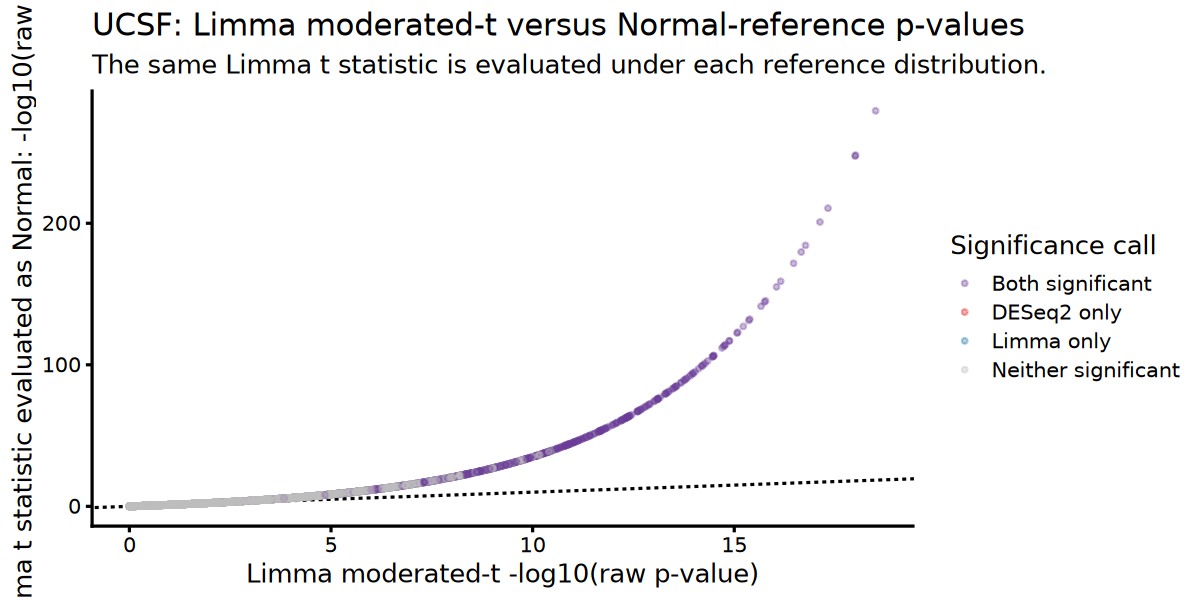

In [56]:
# UCSF: effect of evaluating Limma's moderated t statistic against Normal
# instead of its moderated-t reference distribution. The statistic itself is
# held fixed; only the reference distribution changes.

ucsf_reference_distribution <- ucsf_method_comparison %>%
  mutate(
    limma_total_df = ucsf_fit$df.total[
      match(ensembl_gene_id, rownames(ucsf_fit$coefficients))
    ],
    limma_p_if_normal = 2 * pnorm(-abs(limma_moderated_t)),
    neg_log10_p_limma_t = -log10(pmax(p_value_limma, .Machine$double.xmin)),
    neg_log10_p_limma_if_normal = -log10(
      pmax(limma_p_if_normal, .Machine$double.xmin)
    )
  ) %>%
  filter(
    is.finite(limma_moderated_t),
    is.finite(limma_total_df),
    limma_total_df > 0,
    is.finite(p_value_limma)
  )

# The dashed y = x line marks no change from the reference distribution.
p_ucsf_t_vs_normal_reference <- ucsf_reference_distribution %>%
  ggplot(
    aes(
      x = neg_log10_p_limma_t,
      y = neg_log10_p_limma_if_normal,
      color = significance_pattern
    )
  ) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  geom_point(alpha = 0.35, size = 0.9) +
  scale_color_manual(
    values = c(
      "Both significant" = "#6A3D9A",
      "DESeq2 only" = "#E31A1C",
      "Limma only" = "#1F78B4",
      "Neither significant" = "grey75"
    )
  ) +
  labs(
    title = "UCSF: Limma moderated-t versus Normal-reference p-values",
    subtitle = "The same Limma t statistic is evaluated under each reference distribution.",
    x = "Limma moderated-t -log10(raw p-value)",
    y = "Same Limma t statistic evaluated as Normal: -log10(raw p-value)",
    color = "Significance call"
  )

p_ucsf_t_vs_normal_reference

ucsf_reference_distribution %>%
  summarise(
    median_limma_total_df = median(limma_total_df),
    median_increase_in_neg_log10_p_under_normal = median(
      neg_log10_p_limma_if_normal - neg_log10_p_limma_t
    )
  )


method,n_tested,pi0_storey,n_BH_FDR_lt_0_05,n_Storey_qvalue_lt_0_05,n_local_FDR_lt_0_05,n_local_FDR_lt_0_10,n_qvalue_only_vs_BH,n_BH_only_vs_qvalue
<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
DESeq2,14833,0.6530643,442,496,340,450,54,0
Limma-voom,14840,0.6034452,9,12,7,60,3,0


method,gene_label,ensembl_gene_id,logFC,p_value,padj_bh,qvalue_storey,local_fdr
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DESeq2,EPHA5,ENSG00000145242,1.977031,0.002641161,0.05048497,0.03296993,0.09734307
DESeq2,COL25A1,ENSG00000188517,1.232697,0.002686621,0.05097737,0.03329150,0.09836324
DESeq2,EFNB3,ENSG00000108947,-1.559846,0.002687304,0.05097737,0.03329150,0.09837850
DESeq2,C11orf87,ENSG00000185742,-2.131939,0.002720024,0.05141877,0.03357976,0.09910674
DESeq2,LINC02984,ENSG00000237807,1.156916,0.002729370,0.05144185,0.03359484,0.09931384
DESeq2,BTN3A2,ENSG00000186470,-1.087173,0.002735612,0.05149408,0.03362895,0.09945195
DESeq2,UBASH3B,ENSG00000154127,1.541982,0.002748315,0.05160222,0.03369957,0.09973244
DESeq2,LINC00881,ENSG00000241135,-2.387990,0.002752664,0.05161854,0.03371023,0.09982830
DESeq2,ENSG00000291213,ENSG00000291213,-1.970947,0.002763237,0.05174579,0.03379333,0.10006099


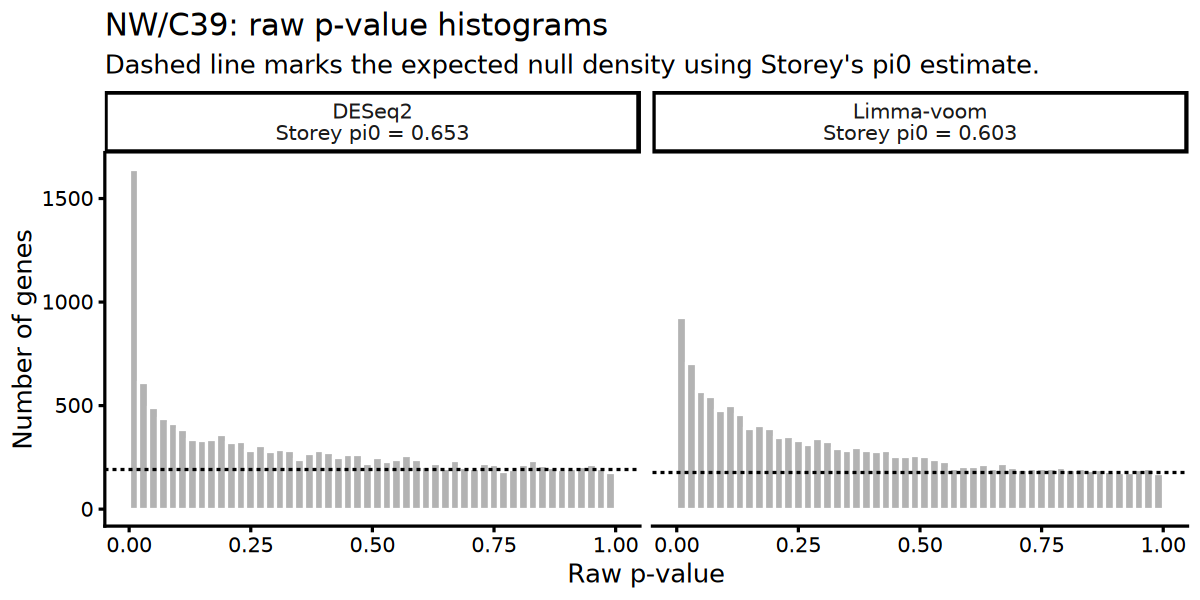

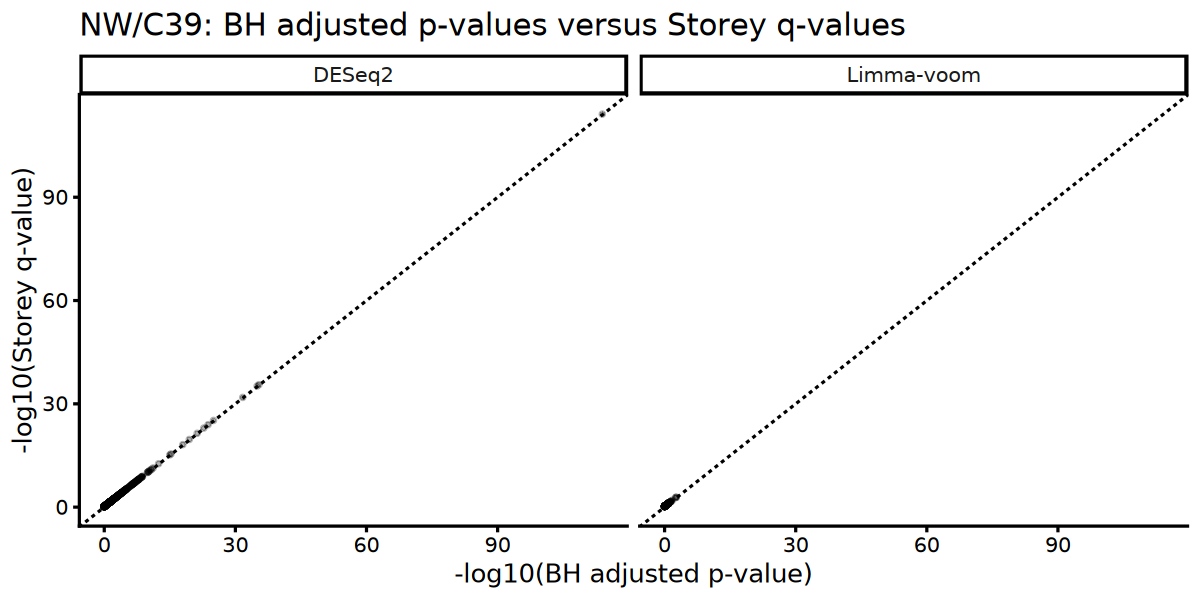

In [57]:
# NW/C39: alternative FDR estimates from qvalue
#
# BH adjusted p-values control FDR with pi0 implicitly fixed at 1. Storey's
# q-value estimates pi0 (the null-gene proportion) from the raw-p distribution,
# which can yield more calls when pi0 < 1. local FDR estimates the probability
# that an individual gene is null; it is not a global-FDR-adjusted p-value.
# All call counts below retain the existing absolute log2FC >= 1 criterion.

if (!requireNamespace("qvalue", quietly = TRUE)) {
  stop("The qvalue package is required. Install it with BiocManager::install('qvalue').")
}

nw_qvalue_input <- bind_rows(
  c39_method_comparison %>%
    transmute(
      method = "DESeq2",
      ensembl_gene_id,
      logFC = logFC_deseq2,
      p_value = p_value_deseq2,
      padj_bh = padj_deseq2
    ),
  c39_method_comparison %>%
    transmute(
      method = "Limma-voom",
      ensembl_gene_id,
      logFC = logFC_limma,
      p_value = p_value_limma,
      padj_bh = padj_limma
    )
) %>%
  filter(is.finite(p_value), p_value >= 0, p_value <= 1)

# Estimate q-values and local FDR separately for each method's p-value vector.
nw_qvalue_diagnostics <- nw_qvalue_input %>%
  group_by(method) %>%
  group_modify(~ {
    qvalue_fit <- qvalue::qvalue(.x$p_value)
    .x %>%
      mutate(
        pi0_storey = qvalue_fit$pi0,
        qvalue_storey = qvalue_fit$qvalues,
        local_fdr = qvalue_fit$lfdr,
        DE_bh = padj_bh < 0.05 & abs(logFC) >= 1,
        DE_qvalue = qvalue_storey < 0.05 & abs(logFC) >= 1,
        DE_local_fdr_0_05 = local_fdr < 0.05 & abs(logFC) >= 1,
        DE_local_fdr_0_10 = local_fdr < 0.10 & abs(logFC) >= 1
      )
  }) %>%
  ungroup()

nw_qvalue_summary <- nw_qvalue_diagnostics %>%
  group_by(method) %>%
  summarise(
    n_tested = n(),
    pi0_storey = first(pi0_storey),
    n_BH_FDR_lt_0_05 = sum(DE_bh, na.rm = TRUE),
    n_Storey_qvalue_lt_0_05 = sum(DE_qvalue, na.rm = TRUE),
    n_local_FDR_lt_0_05 = sum(DE_local_fdr_0_05, na.rm = TRUE),
    n_local_FDR_lt_0_10 = sum(DE_local_fdr_0_10, na.rm = TRUE),
    n_qvalue_only_vs_BH = sum(DE_qvalue & !DE_bh, na.rm = TRUE),
    n_BH_only_vs_qvalue = sum(DE_bh & !DE_qvalue, na.rm = TRUE),
    .groups = "drop"
  )

nw_qvalue_summary

# Raw p-value histograms. Under a complete null, these should be roughly
# uniform on [0, 1]. Enrichment near 0 indicates true signal; Storey's pi0
# is estimated from the flatter right side of the histogram.
nw_pvalue_hist_guides <- nw_qvalue_summary %>%
  mutate(
    method_label = sprintf("%s\nStorey pi0 = %.3f", method, pi0_storey),
    expected_null_bin_count = n_tested * 0.02 * pi0_storey
  )

p_nw_pvalue_hist <- nw_qvalue_diagnostics %>%
  left_join(
    nw_pvalue_hist_guides %>% select(method, method_label, expected_null_bin_count),
    by = "method"
  ) %>%
  ggplot(aes(x = p_value)) +
  geom_histogram(
    binwidth = 0.02,
    boundary = 0,
    closed = "left",
    fill = "grey70",
    color = "white"
  ) +
  geom_hline(
    data = nw_pvalue_hist_guides,
    aes(yintercept = expected_null_bin_count),
    linetype = "dashed"
  ) +
  facet_wrap(~ method_label) +
  labs(
    title = "NW/C39: raw p-value histograms",
    subtitle = "Dashed line marks the expected null density using Storey's pi0 estimate.",
    x = "Raw p-value",
    y = "Number of genes"
  )

p_nw_pvalue_hist

# Genes added by Storey's q-value threshold relative to BH.
nw_qvalue_only_genes <- nw_qvalue_diagnostics %>%
  filter(DE_qvalue, !DE_bh) %>%
  left_join(
    resDESeq2_C39 %>% select(ensembl_gene_id, hgnc_symbol, gene_label),
    by = "ensembl_gene_id"
  ) %>%
  arrange(method, qvalue_storey) %>%
  select(
    method,
    gene_label,
    ensembl_gene_id,
    logFC,
    p_value,
    padj_bh,
    qvalue_storey,
    local_fdr
  )

# Display the first 50; the complete result remains in nw_qvalue_only_genes.
nw_qvalue_only_genes %>% slice_head(n = 50)

# Compare the global BH and Storey q-value adjustments directly. Points below
# the dashed line receive a smaller Storey q-value than BH adjusted p-value.
p_nw_bh_vs_qvalue <- nw_qvalue_diagnostics %>%
  filter(is.finite(padj_bh), is.finite(qvalue_storey)) %>%
  ggplot(aes(x = -log10(pmax(padj_bh, .Machine$double.xmin)),
             y = -log10(pmax(qvalue_storey, .Machine$double.xmin)))) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed") +
  geom_point(alpha = 0.3, size = 0.8) +
  facet_wrap(~ method) +
  labs(
    title = "NW/C39: BH adjusted p-values versus Storey q-values",
    x = "-log10(BH adjusted p-value)",
    y = "-log10(Storey q-value)"
  )

p_nw_bh_vs_qvalue


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



contrast,method,n_input_samples,n_WT,n_KO,n_genes_tested,n_BH_FDR_lt_0_05,n_shared_significant,logFC_correlation
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>
WT C39 vs KO C14+C39,DESeq2,9,3,6,14791,492,57,0.9713025
WT C39 vs KO C14+C39,Limma-voom,9,3,6,14805,58,57,0.9713025


method,n_tested,pi0_storey,n_BH_FDR_lt_0_05,n_Storey_qvalue_lt_0_05,n_local_FDR_lt_0_05,n_local_FDR_lt_0_10,n_qvalue_only_vs_BH
<chr>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>
DESeq2,14791,0.6125397,492,573,397,517,81
Limma-voom,14805,0.5969022,58,140,88,239,82


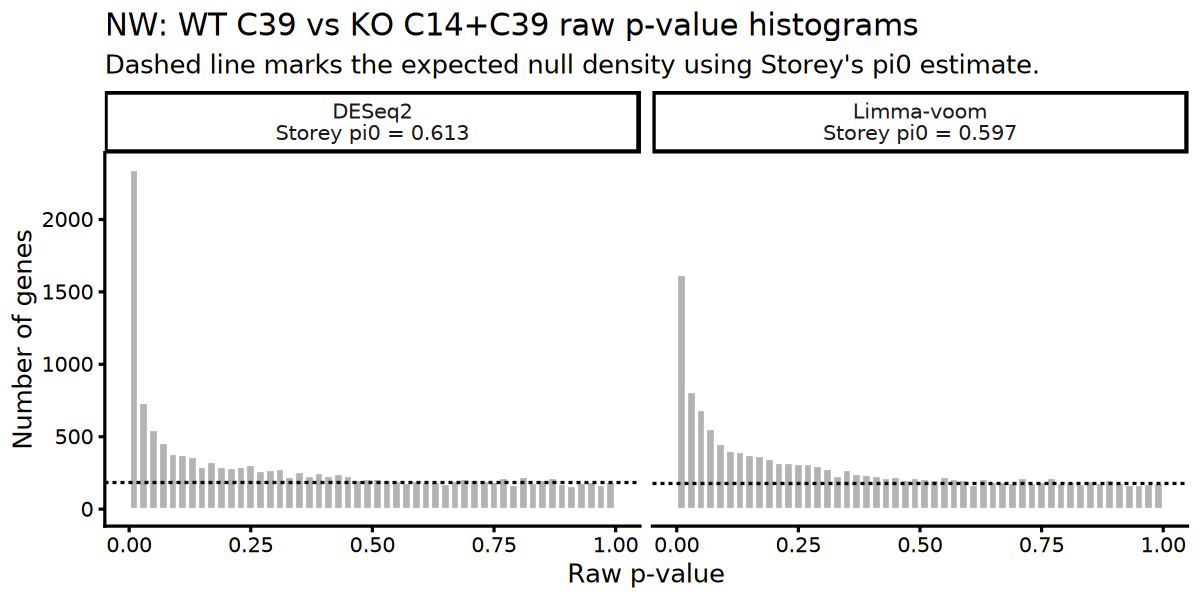

In [58]:
# NW: WT C39 versus KO C14+C39
# Same DESeq2 / Limma-voom comparison and Storey q-value diagnostics as C39-only.

c39_vs_c14c39_conditions <- c("NW_C39_DMSO", "NW_C14_AUXIN", "NW_C39_AUXIN")
c39_vs_c14c39_samples <- which(meta$Dcondition %in% c39_vs_c14c39_conditions)
c39_vs_c14c39_counts <- as.matrix(cts_dat[, c39_vs_c14c39_samples, drop = FALSE])
c39_vs_c14c39_coldata <- meta[c39_vs_c14c39_samples, , drop = FALSE]
rownames(c39_vs_c14c39_coldata) <- colnames(c39_vs_c14c39_counts)

c39_vs_c14c39_coldata$condition <- factor(
  ifelse(c39_vs_c14c39_coldata$Dcondition %in% c("NW_C14_AUXIN", "NW_C39_AUXIN"), "KO", "WT"),
  levels = c("WT", "KO")
)

c39_vs_c14c39_design <- model.matrix(~ 0 + condition, data = c39_vs_c14c39_coldata)
colnames(c39_vs_c14c39_design) <- c("WT", "KO")

stopifnot(
  all(colnames(c39_vs_c14c39_counts) == rownames(c39_vs_c14c39_coldata)),
  all(c39_vs_c14c39_conditions %in% c39_vs_c14c39_coldata$Dcondition),
  all(table(c39_vs_c14c39_coldata$condition) > 0),
  all(c39_vs_c14c39_counts == round(c39_vs_c14c39_counts))
)

storage.mode(c39_vs_c14c39_counts) <- "integer"

# DESeq2
dds_C39_vs_C14C39 <- DESeq2::DESeqDataSetFromMatrix(
  countData = c39_vs_c14c39_counts,
  colData = c39_vs_c14c39_coldata,
  design = ~ condition
)
dds_C39_vs_C14C39 <- DESeq2::DESeq(dds_C39_vs_C14C39)

resDESeq2_C39_vs_C14C39 <- as.data.frame(
  DESeq2::results(
    dds_C39_vs_C14C39,
    contrast = c("condition", "KO", "WT"),
    independentFiltering = FALSE
  )
)
resDESeq2_C39_vs_C14C39$ensembl_gene_id <- rownames(resDESeq2_C39_vs_C14C39)
resDESeq2_C39_vs_C14C39$hgnc_symbol <- gene_anno$hgnc_symbol[
  match(resDESeq2_C39_vs_C14C39$ensembl_gene_id, gene_anno$ensembl_gene_id)
]
resDESeq2_C39_vs_C14C39$gene_label <- ifelse(
  is.na(resDESeq2_C39_vs_C14C39$hgnc_symbol) | resDESeq2_C39_vs_C14C39$hgnc_symbol == "",
  resDESeq2_C39_vs_C14C39$ensembl_gene_id,
  resDESeq2_C39_vs_C14C39$hgnc_symbol
)
resDESeq2_C39_vs_C14C39 <- filter_results_by_group_mean_cpm(
  resDESeq2_C39_vs_C14C39,
  c39_vs_c14c39_counts,
  c39_vs_c14c39_coldata$condition,
  min_cpm = 1,
  gene_col = "ensembl_gene_id"
)

# Limma-voom with post-test CPM filtering
c39_vs_c14c39_y <- edgeR::DGEList(c39_vs_c14c39_counts)
c39_vs_c14c39_y <- edgeR::calcNormFactors(c39_vs_c14c39_y)
c39_vs_c14c39_voom <- limma::voom(c39_vs_c14c39_y, c39_vs_c14c39_design, plot = FALSE)
c39_vs_c14c39_block <- factor(sub("^NW_(C14|C39)_(AUXIN|DMSO)$", "\\1", c39_vs_c14c39_coldata$Dcondition))
stopifnot(!anyNA(c39_vs_c14c39_block))
c39_vs_c14c39_fit <- fit_limma_with_optional_duplicate_correlation(
  c39_vs_c14c39_y,
  c39_vs_c14c39_design,
  block = c39_vs_c14c39_block,
  fit_label = "NW C39 vs C14+C39"
)
c39_vs_c14c39_contrast <- limma::makeContrasts(KOvsWT = KO - WT, levels = c39_vs_c14c39_design)
c39_vs_c14c39_fit <- limma::eBayes(limma::contrasts.fit(c39_vs_c14c39_fit, c39_vs_c14c39_contrast))

ttLimma_C39_vs_C14C39 <- limma::topTable(
  c39_vs_c14c39_fit,
  coef = "KOvsWT",
  number = Inf,
  adjust.method = "BH",
  sort.by = "none"
)
ttLimma_C39_vs_C14C39$ensembl_gene_id <- rownames(ttLimma_C39_vs_C14C39)
ttLimma_C39_vs_C14C39 <- filter_results_by_group_mean_cpm(
  ttLimma_C39_vs_C14C39,
  c39_vs_c14c39_counts,
  c39_vs_c14c39_coldata$condition,
  min_cpm = 1,
  gene_col = "ensembl_gene_id"
)

c39_vs_c14c39_comparison <- inner_join(
  resDESeq2_C39_vs_C14C39 %>%
    transmute(
      ensembl_gene_id,
      gene_label,
      logFC_deseq2 = log2FoldChange,
      p_value_deseq2 = pvalue,
      padj_deseq2 = padj
    ),
  ttLimma_C39_vs_C14C39 %>%
    transmute(
      ensembl_gene_id,
      logFC_limma = logFC,
      limma_moderated_t = t,
      p_value_limma = P.Value,
      padj_limma = adj.P.Val
    ),
  by = "ensembl_gene_id"
) %>%
  mutate(
    deseq2_wald_z = resDESeq2_C39_vs_C14C39$log2FoldChange[
      match(ensembl_gene_id, resDESeq2_C39_vs_C14C39$ensembl_gene_id)
    ] / resDESeq2_C39_vs_C14C39$lfcSE[
      match(ensembl_gene_id, resDESeq2_C39_vs_C14C39$ensembl_gene_id)
    ],
    DE_deseq2 = padj_deseq2 < 0.05 & abs(logFC_deseq2) >= 1,
    DE_limma = padj_limma < 0.05 & abs(logFC_limma) >= 1
  )

c39_vs_c14c39_de_summary <- tibble(
  contrast = "WT C39 vs KO C14+C39",
  method = c("DESeq2", "Limma-voom"),
  n_input_samples = ncol(c39_vs_c14c39_counts),
  n_WT = sum(c39_vs_c14c39_coldata$condition == "WT"),
  n_KO = sum(c39_vs_c14c39_coldata$condition == "KO"),
  n_genes_tested = c(
    sum(!is.na(resDESeq2_C39_vs_C14C39$pvalue)),
    sum(!is.na(ttLimma_C39_vs_C14C39$P.Value))
  ),
  n_BH_FDR_lt_0_05 = c(
    sum(c39_vs_c14c39_comparison$DE_deseq2, na.rm = TRUE),
    sum(c39_vs_c14c39_comparison$DE_limma, na.rm = TRUE)
  ),
  n_shared_significant = sum(
    c39_vs_c14c39_comparison$DE_deseq2 & c39_vs_c14c39_comparison$DE_limma,
    na.rm = TRUE
  ),
  logFC_correlation = cor(
    c39_vs_c14c39_comparison$logFC_deseq2,
    c39_vs_c14c39_comparison$logFC_limma,
    use = "complete.obs"
  )
)

c39_vs_c14c39_de_summary

# Storey q-values / local FDR from each method's raw p-values
c39_vs_c14c39_qvalue_input <- bind_rows(
  c39_vs_c14c39_comparison %>%
    transmute(
      method = "DESeq2",
      ensembl_gene_id,
      logFC = logFC_deseq2,
      p_value = p_value_deseq2,
      padj_bh = padj_deseq2
    ),
  c39_vs_c14c39_comparison %>%
    transmute(
      method = "Limma-voom",
      ensembl_gene_id,
      logFC = logFC_limma,
      p_value = p_value_limma,
      padj_bh = padj_limma
    )
) %>%
  filter(is.finite(p_value), p_value >= 0, p_value <= 1)

c39_vs_c14c39_qvalue_diagnostics <- c39_vs_c14c39_qvalue_input %>%
  group_by(method) %>%
  group_modify(~ {
    qvalue_fit <- qvalue::qvalue(.x$p_value)
    .x %>%
      mutate(
        pi0_storey = qvalue_fit$pi0,
        qvalue_storey = qvalue_fit$qvalues,
        local_fdr = qvalue_fit$lfdr,
        DE_bh = padj_bh < 0.05 & abs(logFC) >= 1,
        DE_qvalue = qvalue_storey < 0.05 & abs(logFC) >= 1,
        DE_local_fdr_0_05 = local_fdr < 0.05 & abs(logFC) >= 1,
        DE_local_fdr_0_10 = local_fdr < 0.10 & abs(logFC) >= 1
      )
  }) %>%
  ungroup()

c39_vs_c14c39_qvalue_summary <- c39_vs_c14c39_qvalue_diagnostics %>%
  group_by(method) %>%
  summarise(
    n_tested = n(),
    pi0_storey = first(pi0_storey),
    n_BH_FDR_lt_0_05 = sum(DE_bh, na.rm = TRUE),
    n_Storey_qvalue_lt_0_05 = sum(DE_qvalue, na.rm = TRUE),
    n_local_FDR_lt_0_05 = sum(DE_local_fdr_0_05, na.rm = TRUE),
    n_local_FDR_lt_0_10 = sum(DE_local_fdr_0_10, na.rm = TRUE),
    n_qvalue_only_vs_BH = sum(DE_qvalue & !DE_bh, na.rm = TRUE),
    .groups = "drop"
  )

c39_vs_c14c39_qvalue_summary

c39_vs_c14c39_pvalue_hist_guides <- c39_vs_c14c39_qvalue_summary %>%
  mutate(
    method_label = sprintf("%s\nStorey pi0 = %.3f", method, pi0_storey),
    expected_null_bin_count = n_tested * 0.02 * pi0_storey
  )

p_c39_vs_c14c39_pvalue_hist <- c39_vs_c14c39_qvalue_diagnostics %>%
  left_join(
    c39_vs_c14c39_pvalue_hist_guides %>%
      select(method, method_label, expected_null_bin_count),
    by = "method"
  ) %>%
  ggplot(aes(x = p_value)) +
  geom_histogram(
    binwidth = 0.02,
    boundary = 0,
    closed = "left",
    fill = "grey70",
    color = "white"
  ) +
  geom_hline(
    data = c39_vs_c14c39_pvalue_hist_guides,
    aes(yintercept = expected_null_bin_count),
    linetype = "dashed"
  ) +
  facet_wrap(~ method_label) +
  labs(
    title = "NW: WT C39 vs KO C14+C39 raw p-value histograms",
    subtitle = "Dashed line marks the expected null density using Storey's pi0 estimate.",
    x = "Raw p-value",
    y = "Number of genes"
  )

p_c39_vs_c14c39_pvalue_hist


In [59]:
nw_qvalue_diagnostics[nw_qvalue_diagnostics$qvalue_storey < 0.05 & abs(nw_qvalue_diagnostics$logFC) > 1,]

method,ensembl_gene_id,logFC,p_value,padj_bh,pi0_storey,qvalue_storey,local_fdr,DE_bh,DE_qvalue,DE_local_fdr_0_05,DE_local_fdr_0_10
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>
DESeq2,ENSG00000164161,5.501672,7.468738e-119,1.107838e-114,0.6530643,7.234894e-115,3.835003e-06,TRUE,TRUE,TRUE,TRUE
DESeq2,ENSG00000109063,2.656104,5.709029e-40,4.234101e-36,0.6530643,2.765140e-36,3.835003e-06,TRUE,TRUE,TRUE,TRUE
DESeq2,ENSG00000163536,-1.945966,7.107823e-28,1.757172e-24,0.6530643,1.147547e-24,3.835003e-06,TRUE,TRUE,TRUE,TRUE
DESeq2,ENSG00000180053,-1.895480,7.193392e-22,1.066996e-18,0.6530643,6.968169e-19,3.835003e-06,TRUE,TRUE,TRUE,TRUE
DESeq2,ENSG00000146374,-3.674790,3.427183e-29,1.016708e-25,0.6530643,6.639759e-26,3.835003e-06,TRUE,TRUE,TRUE,TRUE
DESeq2,ENSG00000155011,3.922564,2.140570e-39,1.058369e-35,0.6530643,6.911831e-36,3.835003e-06,TRUE,TRUE,TRUE,TRUE
DESeq2,ENSG00000121068,-2.916231,7.857897e-27,1.665088e-23,0.6530643,1.087410e-23,3.835003e-06,TRUE,TRUE,TRUE,TRUE
DESeq2,ENSG00000154529,3.548229,5.645379e-36,2.093448e-32,0.6530643,1.367156e-32,3.835003e-06,TRUE,TRUE,TRUE,TRUE
DESeq2,ENSG00000061455,-2.382976,2.093378e-23,3.450120e-20,0.6530643,2.253150e-20,3.835003e-06,TRUE,TRUE,TRUE,TRUE


In [60]:
# Storey q-value threshold sensitivity: q < 0.05 versus q < 0.10.
# Uses the same absolute log2FC >= 1 criterion as n_Storey_qvalue_lt_0_05.
storey_qvalue_threshold_comparison <- bind_rows(
  `NW/C39` = nw_qvalue_diagnostics,
  `WT C39 vs KO C14+C39` = c39_vs_c14c39_qvalue_diagnostics,
  .id = "contrast"
) %>%
  mutate(
    Storey_qvalue_lt_0_05 = qvalue_storey < 0.05 & abs(logFC) >= 1,
    Storey_qvalue_lt_0_10 = qvalue_storey < 0.10 & abs(logFC) >= 1
  ) %>%
  group_by(contrast, method) %>%
  summarise(
    n_Storey_qvalue_lt_0_05 = sum(Storey_qvalue_lt_0_05, na.rm = TRUE),
    n_Storey_qvalue_lt_0_10 = sum(Storey_qvalue_lt_0_10, na.rm = TRUE),
    n_added_by_relaxing_to_0_10 = sum(
      Storey_qvalue_lt_0_10 & !Storey_qvalue_lt_0_05,
      na.rm = TRUE
    ),
    .groups = "drop"
  )

storey_qvalue_threshold_comparison

# Genes newly included when relaxing Storey q-value cutoff from 0.05 to 0.10.
storey_qvalue_added_genes_0_05_to_0_10 <- bind_rows(
  `NW/C39` = nw_qvalue_diagnostics,
  `WT C39 vs KO C14+C39` = c39_vs_c14c39_qvalue_diagnostics,
  .id = "contrast"
) %>%
  filter(qvalue_storey >= 0.05, qvalue_storey < 0.10, abs(logFC) >= 1) %>%
  left_join(
    gene_anno %>% select(ensembl_gene_id, hgnc_symbol),
    by = "ensembl_gene_id"
  ) %>%
  mutate(
    gene_label = ifelse(
      is.na(hgnc_symbol) | hgnc_symbol == "",
      ensembl_gene_id,
      hgnc_symbol
    )
  ) %>%
  arrange(contrast, method, qvalue_storey) %>%
  select(
    contrast,
    method,
    gene_label,
    ensembl_gene_id,
    logFC,
    p_value,
    padj_bh,
    qvalue_storey,
    local_fdr
  )

# Display the first 50; the complete result remains in
# storey_qvalue_added_genes_0_05_to_0_10.
storey_qvalue_added_genes_0_05_to_0_10 %>% slice_head(n = 50)

contrast,method,n_Storey_qvalue_lt_0_05,n_Storey_qvalue_lt_0_10,n_added_by_relaxing_to_0_10
<chr>,<chr>,<int>,<int>,<int>
NW/C39,DESeq2,496,635,139
NW/C39,Limma-voom,12,94,82
WT C39 vs KO C14+C39,DESeq2,573,703,130
WT C39 vs KO C14+C39,Limma-voom,140,370,230


contrast,method,gene_label,ensembl_gene_id,logFC,p_value,padj_bh,qvalue_storey,local_fdr
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NW/C39,DESeq2,CA12,ENSG00000074410,1.654703,0.004844174,0.07767960,0.05072978,0.1376663
NW/C39,DESeq2,TBX18,ENSG00000112837,1.812533,0.004902166,0.07823919,0.05109522,0.1385292
NW/C39,DESeq2,CACNA1S,ENSG00000081248,1.485544,0.004906413,0.07823919,0.05109522,0.1385920
NW/C39,DESeq2,ANKRD9,ENSG00000156381,-1.119809,0.004998007,0.07920452,0.05172565,0.1399384
NW/C39,DESeq2,CYGB,ENSG00000161544,-1.236971,0.005023842,0.07940953,0.05185953,0.1403148
NW/C39,DESeq2,KCNJ5,ENSG00000120457,-2.006750,0.005031384,0.07940953,0.05185953,0.1404244
NW/C39,DESeq2,ENSG00000283128,ENSG00000283128,-3.077794,0.005167906,0.08077507,0.05275132,0.1423872
NW/C39,DESeq2,GPRC5A,ENSG00000013588,1.203340,0.005180091,0.08081944,0.05278029,0.1425605
NW/C39,DESeq2,PAPPA,ENSG00000182752,1.198016,0.005181641,0.08081944,0.05278029,0.1425825


In [61]:
# Independent LMO2 limma/voom normalization check.
# This cell rebuilds the LMO2 normalized CPM and limma logCPM values from raw files.
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(edgeR)
  library(limma)
})

lmo2_personal_path <- "/fh/working/sun_w/sshen/MorPhiC"
lmo2_data_path <- file.path(
  "/fh/fast/sun_w/MorPhiC/data/MorPhiC_exchange_experiment",
  "DRACC-processed/NW_exchange_experiment_DRACC_processed_March2026/Tables"
)

lmo2_meta <- data.table::fread(
  file.path(lmo2_personal_path, "NW_meta_data.tsv"),
  data.table = FALSE
) %>%
  mutate(
    Center = stringr::str_squish(Center),
    DPC = dplyr::recode(Center, "NorthWestern" = "NW", .default = Center),
    Dcondition = stringr::str_squish(Dcondition),
    ko_status = ifelse(ko_gene == "WT", "WT", "KO")
  )

lmo2_counts_df <- data.table::fread(
  file.path(lmo2_data_path, "genesCounts.csv"),
  data.table = FALSE
)
colnames(lmo2_counts_df) <- gsub("_S[0-9]+_L[0-9]+$", "", colnames(lmo2_counts_df))

stopifnot(
  setequal(lmo2_meta$Name, names(lmo2_counts_df)[-1]),
  !any(duplicated(lmo2_meta$Name)),
  !any(duplicated(names(lmo2_counts_df)[-1]))
)
lmo2_meta <- lmo2_meta[match(names(lmo2_counts_df)[-1], lmo2_meta$Name), ]

lmo2_counts <- data.matrix(lmo2_counts_df[, -1])
rownames(lmo2_counts) <- lmo2_counts_df$Name

lmo2_gene_anno <- data.table::fread(
  "/fh/fast/sun_w/sshen/MorPhiC/gencode_v44_primary_assembly_info.tsv",
  data.table = FALSE
)
lmo2_gene_id <- unique(lmo2_gene_anno$ensembl_gene_id[lmo2_gene_anno$hgnc_symbol == "LMO2"])
stopifnot(length(lmo2_gene_id) == 1, lmo2_gene_id %in% rownames(lmo2_counts))

# Use q75-passing annotated genes for DE.
lmo2_counts <- lmo2_counts[
  rownames(lmo2_counts) %in% lmo2_gene_anno$ensembl_gene_id,
  ,
  drop = FALSE
]
lmo2_gene_q75 <- apply(lmo2_counts, 1, function(x) quantile(x, probs = 0.75))
lmo2_passes_global_q75 <- lmo2_gene_q75[lmo2_gene_id] > 0
lmo2_gene_filter_summary <- tibble(
  gene_symbol = "LMO2",
  ensembl_gene_id = lmo2_gene_id,
  q75_raw_count = as.numeric(lmo2_gene_q75[lmo2_gene_id]),
  passes_global_q75 = lmo2_passes_global_q75
)
print(lmo2_gene_filter_summary, width = Inf)

stopifnot(lmo2_gene_id %in% rownames(lmo2_counts))

# Limma/voom normalized expression across all samples.
lmo2_y_all <- edgeR::DGEList(lmo2_counts)
lmo2_y_all <- edgeR::calcNormFactors(lmo2_y_all)
lmo2_voom_all <- limma::voom(lmo2_y_all, plot = FALSE)
lmo2_cpm_all <- edgeR::cpm(lmo2_y_all, log = FALSE)

lmo2_limma_by_sample <- tibble(
  sample = colnames(lmo2_counts),
  DPC = lmo2_meta$DPC,
  Dcondition = lmo2_meta$Dcondition,
  ko_status = lmo2_meta$ko_status,
  raw_count = as.numeric(lmo2_counts[lmo2_gene_id, ]),
  normalized_CPM = as.numeric(lmo2_cpm_all[lmo2_gene_id, ]),
  limma_logCPM = as.numeric(lmo2_voom_all$E[lmo2_gene_id, ])
) %>%
  arrange(DPC, Dcondition, sample)

# This is the condition/DPC-level table to inspect first.
lmo2_limma_by_condition <- lmo2_limma_by_sample %>%
  group_by(DPC, Dcondition, ko_status) %>%
  summarise(
    n_samples = n(),
    mean_raw_count = mean(raw_count),
    mean_normalized_CPM = mean(normalized_CPM),
    mean_limma_logCPM = mean(limma_logCPM),
    min_limma_logCPM = min(limma_logCPM),
    max_limma_logCPM = max(limma_logCPM),
    .groups = "drop"
  ) %>%
  arrange(DPC, Dcondition)

print(lmo2_limma_by_condition, n = Inf, width = Inf)

# Reconstruct AveExpr-like values: limma's AveExpr is the average of sample-level
# voom logCPM values for the samples in a given comparison, not an average CPM.
summarise_lmo2_comparison <- function(comparison_name, dconditions, ko_dconditions = NULL) {
  sample_idx <- lmo2_meta$Dcondition %in% dconditions
  meta_sub <- lmo2_meta[sample_idx, , drop = FALSE]
  counts_sub <- lmo2_counts[, sample_idx, drop = FALSE]
  group <- if (is.null(ko_dconditions)) {
    ifelse(meta_sub$ko_gene == "WT", "WT", "KO")
  } else {
    ifelse(meta_sub$Dcondition %in% ko_dconditions, "KO", "WT")
  }
  group <- factor(group, levels = c("WT", "KO"))

  y_sub <- edgeR::DGEList(counts_sub)
  y_sub <- edgeR::calcNormFactors(y_sub)
  v_sub <- limma::voom(y_sub, model.matrix(~ 0 + group), plot = FALSE)
  cpm_sub <- edgeR::cpm(y_sub, log = FALSE)
  lmo2_logcpm <- as.numeric(v_sub$E[lmo2_gene_id, ])
  lmo2_cpm <- as.numeric(cpm_sub[lmo2_gene_id, ])

  tibble(
    comparison = comparison_name,
    n_samples = length(group),
    n_WT = sum(group == "WT"),
    n_KO = sum(group == "KO"),
    mean_CPM_WT = mean(lmo2_cpm[group == "WT"]),
    mean_CPM_KO = mean(lmo2_cpm[group == "KO"]),
    mean_limma_logCPM_WT = mean(lmo2_logcpm[group == "WT"]),
    mean_limma_logCPM_KO = mean(lmo2_logcpm[group == "KO"]),
    aveexpr_from_sample_logCPM = mean(lmo2_logcpm),
    weighted_aveexpr_check = (
      sum(group == "WT") * mean(lmo2_logcpm[group == "WT"]) +
        sum(group == "KO") * mean(lmo2_logcpm[group == "KO"])
    ) / length(group),
    cpm_filter_value = max(mean(lmo2_cpm[group == "WT"]), mean(lmo2_cpm[group == "KO"])),
    cpm_filter_passes_1 = cpm_filter_value >= 1
  )
}

lmo2_aveexpr_reconstruction <- bind_rows(
  summarise_lmo2_comparison(
    "NW C39: WT C39 vs KO C39",
    c("NW_C39_DMSO", "NW_C39_AUXIN"),
    ko_dconditions = "NW_C39_AUXIN"
  ),
  summarise_lmo2_comparison(
    "NW: WT C39 vs KO C14+C39",
    c("NW_C39_DMSO", "NW_C14_AUXIN", "NW_C39_AUXIN"),
    ko_dconditions = c("NW_C14_AUXIN", "NW_C39_AUXIN")
  ),
  summarise_lmo2_comparison(
    "UCSF: group-only KO vs WT samples",
    c(
      "UCSF_AAVS1_DMSO",
      "UCSF_AAVS1_DOX",
      "UCSF_CLONE_D1_DMSO",
      "UCSF_CLONE_D1_DOX",
      "UCSF_CLONE_B1 DMSO",
      "UCSF_CLONE_B1 DOX"
    )
  )
)

print(lmo2_aveexpr_reconstruction, n = Inf, width = Inf)

# Directly rerun limma for the ISL1 comparisons and print the LMO2 topTable row.
rerun_lmo2_limma_simple <- function(comparison_name, dconditions, ko_dconditions) {
  sample_idx <- lmo2_meta$Dcondition %in% dconditions
  meta_sub <- lmo2_meta[sample_idx, , drop = FALSE]
  counts_sub <- lmo2_counts[, sample_idx, drop = FALSE]
  group <- factor(
    ifelse(meta_sub$Dcondition %in% ko_dconditions, "KO", "WT"),
    levels = c("WT", "KO")
  )
  design <- model.matrix(~ 0 + group)
  colnames(design) <- c("WT", "KO")
  block <- NULL
  if (all(grepl("^NW_(C14|C39)_(AUXIN|DMSO)$", meta_sub$Dcondition))) {
    block <- factor(sub("^NW_(C14|C39)_(AUXIN|DMSO)$", "\\1", meta_sub$Dcondition))
  }
  y <- edgeR::DGEList(counts_sub)
  y <- edgeR::calcNormFactors(y)
  v <- limma::voom(y, design, plot = FALSE)
  fit <- fit_limma_with_optional_duplicate_correlation(y, design, block = block, fit_label = comparison_name)
  fit <- limma::eBayes(
    limma::contrasts.fit(
      fit,
      limma::makeContrasts(KOvsWT = KO - WT, levels = design)
    )
  )
  tt <- limma::topTable(fit, coef = "KOvsWT", number = Inf, sort.by = "none")
  tt <- filter_results_by_group_mean_cpm(tt, counts_sub, group, min_cpm = 1)
  if (!lmo2_gene_id %in% rownames(tt)) {
    return(tibble(comparison = comparison_name, passed_filter = FALSE))
  }
  tibble(
    comparison = comparison_name,
    passed_filter = TRUE,
    logFC = tt[lmo2_gene_id, "logFC"],
    AveExpr = tt[lmo2_gene_id, "AveExpr"],
    t = tt[lmo2_gene_id, "t"],
    P.Value = tt[lmo2_gene_id, "P.Value"],
    adj.P.Val = tt[lmo2_gene_id, "adj.P.Val"],
    B = tt[lmo2_gene_id, "B"],
    mean_CPM_WT = tt[lmo2_gene_id, "mean_CPM_WT"],
    mean_CPM_KO = tt[lmo2_gene_id, "mean_CPM_KO"],
    max_mean_CPM = tt[lmo2_gene_id, "max_mean_CPM"]
  )
}

rerun_lmo2_limma_ucsf <- function() {
  dconditions <- c(
    "UCSF_AAVS1_DMSO",
    "UCSF_AAVS1_DOX",
    "UCSF_CLONE_D1_DMSO",
    "UCSF_CLONE_D1_DOX",
    "UCSF_CLONE_B1 DMSO",
    "UCSF_CLONE_B1 DOX"
  )
  sample_idx <- lmo2_meta$Dcondition %in% dconditions
  meta_sub <- lmo2_meta[sample_idx, , drop = FALSE]
  counts_sub <- lmo2_counts[, sample_idx, drop = FALSE]
  clone <- factor(
    sub(
      "^UCSF_(CLONE_)?(D1|B1|AAVS1)[_ ](DMSO|DOX)$",
      "\\2",
      meta_sub$Dcondition
    ),
    levels = c("AAVS1", "D1", "B1")
  )
  doxycycline <- factor(
    ifelse(grepl("DOX$", meta_sub$Dcondition), "DOX", "DMSO"),
    levels = c("DMSO", "DOX")
  )
  ko_status <- factor(meta_sub$ko_gene, levels = c("WT", "KO"))
  design <- model.matrix(~ 0 + ko_status)
  colnames(design) <- c("WT", "KO")
  y <- edgeR::DGEList(counts_sub)
  y <- edgeR::calcNormFactors(y)
  v <- limma::voom(y, design, plot = FALSE)
  fit <- fit_limma_with_optional_duplicate_correlation(y, design, block = clone, fit_label = "LMO2 UCSF")
  fit <- limma::eBayes(
    limma::contrasts.fit(
      fit,
      limma::makeContrasts(KOvsWT = KO - WT, levels = design)
    )
  )
  tt <- limma::topTable(fit, coef = "KOvsWT", number = Inf, sort.by = "none")
  tt <- filter_results_by_group_mean_cpm(tt, counts_sub, ko_status, min_cpm = 1)
  if (!lmo2_gene_id %in% rownames(tt)) {
    return(tibble(comparison = "UCSF: group-only KO vs WT samples", passed_filter = FALSE))
  }
  tibble(
    comparison = "UCSF: group-only KO vs WT samples",
    passed_filter = TRUE,
    logFC = tt[lmo2_gene_id, "logFC"],
    AveExpr = tt[lmo2_gene_id, "AveExpr"],
    t = tt[lmo2_gene_id, "t"],
    P.Value = tt[lmo2_gene_id, "P.Value"],
    adj.P.Val = tt[lmo2_gene_id, "adj.P.Val"],
    B = tt[lmo2_gene_id, "B"],
    mean_CPM_WT = tt[lmo2_gene_id, "mean_CPM_WT"],
    mean_CPM_KO = tt[lmo2_gene_id, "mean_CPM_KO"],
    max_mean_CPM = tt[lmo2_gene_id, "max_mean_CPM"]
  )
}

lmo2_limma_rerun_rows <- bind_rows(
  rerun_lmo2_limma_simple(
    "NW C39: WT C39 vs KO C39",
    c("NW_C39_DMSO", "NW_C39_AUXIN"),
    ko_dconditions = "NW_C39_AUXIN"
  ),
  rerun_lmo2_limma_simple(
    "NW: WT C39 vs KO C14+C39",
    c("NW_C39_DMSO", "NW_C14_AUXIN", "NW_C39_AUXIN"),
    ko_dconditions = c("NW_C14_AUXIN", "NW_C39_AUXIN")
  ),
  rerun_lmo2_limma_ucsf()
)

print(lmo2_limma_rerun_rows, n = Inf, width = Inf)

# Per-sample values are kept for debugging individual samples.
print(lmo2_limma_by_sample, n = Inf, width = Inf)

# A tibble: 1 × 4
  gene_symbol ensembl_gene_id q75_raw_count passes_global_q75
  <chr>       <chr>                   <dbl> <lgl>            
1 LMO2        ENSG00000135363           482 TRUE             
# A tibble: 19 × 9
   DPC    Dcondition         ko_status n_samples mean_raw_count
   <chr>  <chr>              <chr>         <int>          <dbl>
 1 JAX    JAX_CLONE_AD2      KO                3           262 
 2 JAX    JAX_CLONE_DO4      KO                3           191.
 3 MSK    MSK_CLONE_05       KO                3           180 
 4 MSK    MSK_CLONE_07       KO                3           282.
 5 NW     NW_C14_AUXIN       KO                3           212.
 6 NW     NW_C14_DMSO        WT                3           197 
 7 NW     NW_C39_AUXIN       KO                3           348.
 8 NW     NW_C39_DMSO        WT                3           348.
 9 NW     NW_OSTIR_AUXIN     WT                3           414.
10 NW     NW_OSTIR_DMSO      WT                3           307.
11 Parent

In [ ]:
a = c39_vs_c14c39_qvalue_diagnostics[c39_vs_c14c39_qvalue_diagnostics$method == "DESeq2", ]
b = c39_vs_c14c39_qvalue_diagnostics[c39_vs_c14c39_qvalue_diagnostics$method == "Limma-voom", ]

a = a[a$qvalue_storey < 0.05 & abs(a$logFC) > 1, ]
b = b[b$qvalue_storey < 0.05 & abs(b$logFC) > 1, ]
sum(b$ensembl_gene_id %in% a$ensembl_gene_id)

[1] 136

In [73]:
a = c39_vs_c14c39_qvalue_diagnostics[c39_vs_c14c39_qvalue_diagnostics$method == "DESeq2", ]
b = c39_vs_c14c39_qvalue_diagnostics[c39_vs_c14c39_qvalue_diagnostics$method == "Limma-voom", ]

a = a[a$qvalue_storey < 0.05 & abs(a$logFC) > 1, ]
b = b[b$qvalue_storey < 0.1 & abs(b$logFC) > 1, ]
sum(b$ensembl_gene_id %in% a$ensembl_gene_id)

[1] 342